# Task 2.1 — Multimodal sexism identification

This notebook predicts whether a meme is sexist (`YES`) or not (`NO`). It compares OCR text, images, physiological sensors, dense embeddings, transformers, classical learners, and multimodal ensembles.

**Report-aligned result.** The selected equal-weight soft vote combines eight experts. On the development/model-selection set, at the threshold of **0.371642**, it reaches **0.709 macro-F1**, **0.815 F1 for `YES`**, **0.94 recall for `YES`**, and **0.748 accuracy**.

| Retained expert | Function in the gate |
|---|---|
| E5 + CLIP LR (`C=1`) | Main bilingual text-image anchor |
| E5 + CLIP XGBoost | Non-linear correction over the same joint representation |
| Cardiff RoBERTa | English offensive-language specialist |
| E5 + CLIP + sensors LightGBM | Physiological correction branch |
| E5 + DINOv2 LR (`C=3`) | Alternative visual prior |
| E5 + CLIP LightGBM | Boosted multimodal expert |
| E5 + DINOv2 LR (`C=1`) | Regularized alternative-vision expert |
| E5 + CLIP LR (`C=3`) | Higher-capacity linear anchor |

The paired LightGBM ablation improves from **0.678** without sensors to **0.706** with sensors (**+0.028 macro-F1**), justifying exactly one sensor-aware member rather than forcing physiological features into every model.

> The checked-in notebook preserves the audited execution. Runtime paths are configurable, while heavyweight model and embedding caches remain external.

## Experimental design

OCR is a strong baseline but is not sufficient in every case: sexual vocabulary can create false positives without sexist intent, while some false negatives depend on visual composition or pragmatic context. The experiment therefore evaluates text, vision, and sensor representations independently and in fusion.

The primary optimization target is `F1(YES)`. Macro-F1, accuracy, precision, recall, and confusion matrices are reported for a complete view of gate behaviour.

In [ ]:
# Setup opcional. En local usa .\setup_cuda_env.ps1; dentro del notebook no se instala nada salvo que lo pidas.
import importlib.util
import os
import subprocess
import sys

INSTALL_DEPS = os.environ.get("EXIST2026_INSTALL_DEPS", "0") == "1"

packages = {
    "iterative-stratification": "iterstrat",
    "sentence-transformers": "sentence_transformers",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "datasets": "datasets",
    "sentencepiece": "sentencepiece",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "timm": "timm",
    "seaborn": "seaborn",
    "jsonschema": "jsonschema",
    "PyEvALL": "pyevall",
}
missing = [pkg for pkg, module in packages.items() if importlib.util.find_spec(module) is None]
if missing and INSTALL_DEPS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
elif missing:
    print("Dependencias pendientes:", missing)
    print("Ejecuta .\setup_cuda_env.ps1 y abre el kernel 'LNR CUDA (.venv-cuda)'.")
else:
    print("Todas las dependencias opcionales ya estan instaladas.")

In [ ]:
import gc
import hashlib
import json
import math
import os
import random
import re
import subprocess
import tempfile
import time
import warnings
from collections import Counter
from pathlib import Path

# Repository-aware local/Colab configuration.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
WORKSPACE_ROOT = Path(os.environ.get("LNR_WORKSPACE", REPO_ROOT.parent)).resolve()
PROJECT_ROOT = Path(os.environ.get("LNR_PROJECT_ROOT", REPO_ROOT)).resolve()
OUTPUT_DIR = Path(os.environ.get("LNR_OUTPUT_DIR", REPO_ROOT / "outputs" / "task2_1")).resolve()

LOCAL_CACHE_DIR = OUTPUT_DIR / "cache"
PERSISTENT_CACHE_DIR = OUTPUT_DIR / "persistent_cache"
MODEL_CACHE_DIR = OUTPUT_DIR / "model_cache"
HF_HOME = MODEL_CACHE_DIR / "huggingface"
for _cache_path in [OUTPUT_DIR, LOCAL_CACHE_DIR, PERSISTENT_CACHE_DIR, MODEL_CACHE_DIR, HF_HOME]:
    _cache_path.mkdir(parents=True, exist_ok=True)

# Se fija antes de importar transformers/sentence-transformers para reutilizar descargas futuras.
os.environ.setdefault("HF_HOME", str(HF_HOME))
os.environ.setdefault("HF_HUB_CACHE", str(HF_HOME / "hub"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(HF_HOME / "hub"))
os.environ.setdefault("SENTENCE_TRANSFORMERS_HOME", str(MODEL_CACHE_DIR / "sentence_transformers"))
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd

from IPython.display import display
from scipy import sparse
from scipy.special import expit, softmax
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.svm import LinearSVC

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except Exception:
    MultilabelStratifiedShuffleSplit = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    plt = None
    sns = None

try:
    from pyevall.evaluation import PyEvALLEvaluation
    from pyevall.metrics.metricfactory import MetricFactory
    from pyevall.utils.utils import PyEvALLUtils
except Exception:
    PyEvALLEvaluation = None
    MetricFactory = None
    PyEvALLUtils = None

try:
    import torch
    from torch.utils.data import Dataset
    from transformers import (
        AutoImageProcessor,
        AutoModel,
        AutoModelForSequenceClassification,
        AutoTokenizer,
        CLIPModel,
        CLIPProcessor,
        DataCollatorWithPadding,
        EarlyStoppingCallback,
        Trainer,
        TrainingArguments,
        set_seed as hf_set_seed,
    )
except Exception:
    torch = None
    class Dataset:
        pass
    class Trainer:
        pass
    AutoImageProcessor = None
    AutoModel = None
    AutoModelForSequenceClassification = None
    AutoTokenizer = None
    CLIPModel = None
    CLIPProcessor = None
    DataCollatorWithPadding = None
    EarlyStoppingCallback = None
    TrainingArguments = None
    def hf_set_seed(seed):
        return None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 240)

SEED = int(os.environ.get("EXIST2026_SEED", "42"))


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        hf_set_seed(seed)


seed_everything(SEED)
DEVICE = "cuda" if (torch is not None and torch.cuda.is_available()) else "cpu"
print("Device:", DEVICE)
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime PyTorch:", torch.version.cuda)

# Preset principal. En local puede ajustarse con variables de entorno sin editar el notebook.
FULL_MODULAR = os.environ.get("EXIST2026_FULL_MODULAR", "1") == "1"
QUICK_DEBUG = os.environ.get("EXIST2026_QUICK_DEBUG", "0") == "1"
EXPERIMENT_PRESET = "full" if FULL_MODULAR else "balanced"
VALIDATION_SIZE = float(os.environ.get("EXIST2026_VALIDATION_SIZE", "0.20"))

RUN_CLASSICAL = os.environ.get("EXIST2026_RUN_CLASSICAL", "1") == "1"
RUN_DENSE_EMBEDDINGS = os.environ.get("EXIST2026_RUN_DENSE_EMBEDDINGS", "1") == "1"
RUN_IMAGE_EMBEDDINGS = (DEVICE == "cuda") and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_IMAGE_EMBEDDINGS", "1") == "1"
RUN_TRANSFORMERS = (DEVICE == "cuda") and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_TRANSFORMERS", "1") == "1"
RUN_HEAVY_DINO = FULL_MODULAR and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_HEAVY_DINO", "1") == "1"
RUN_HEAVY_TREE_MODELS = FULL_MODULAR and not QUICK_DEBUG and os.environ.get("EXIST2026_RUN_HEAVY_TREE_MODELS", "1") == "1"
USE_MIXED_PRECISION = (DEVICE == "cuda") and os.environ.get("EXIST2026_USE_MIXED_PRECISION", "1") == "1"

TEXT_EMBED_BATCH_SIZE = int(os.environ.get("EXIST2026_TEXT_EMBED_BATCH_SIZE", "64" if DEVICE == "cuda" else "32"))
IMAGE_EMBED_BATCH_SIZE = int(os.environ.get("EXIST2026_IMAGE_EMBED_BATCH_SIZE", "16" if DEVICE == "cuda" else "8"))
TRANSFORMER_TRAIN_BATCH_SIZE = int(os.environ.get("EXIST2026_TRANSFORMER_TRAIN_BATCH_SIZE", "4" if DEVICE == "cuda" else "8"))
TRANSFORMER_EVAL_BATCH_SIZE = int(os.environ.get("EXIST2026_TRANSFORMER_EVAL_BATCH_SIZE", "8" if DEVICE == "cuda" else "16"))
TRANSFORMER_GRAD_ACCUM_STEPS = int(os.environ.get("EXIST2026_TRANSFORMER_GRAD_ACCUM_STEPS", "2" if DEVICE == "cuda" else "1"))

MAX_ROWS_DEBUG = 240 if QUICK_DEBUG else None
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PERSISTENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_EMB_CACHE_DIR = PERSISTENT_CACHE_DIR / "embeddings"
DRIVE_EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = LOCAL_CACHE_DIR
EMBEDDINGS_CACHE_DIR = CACHE_DIR
USE_LOCAL_IMAGE_STAGING = True

print("WORKSPACE_ROOT:", WORKSPACE_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("HF_HOME:", os.environ.get("HF_HOME"))
print("EMBEDDINGS_CACHE_DIR local:", EMBEDDINGS_CACHE_DIR)
print("EMBEDDINGS_CACHE_DIR persistente:", DRIVE_EMB_CACHE_DIR)

OFFICIAL_LABELS_21 = ["NO", "YES"]
OFFICIAL_LABELS_22 = ["NO", "JUDGEMENTAL", "DIRECT"]
OFFICIAL_LABELS_23 = [
    "NO",
    "IDEOLOGICAL-INEQUALITY",
    "STEREOTYPING-DOMINANCE",
    "MISOGYNY-NON-SEXUAL-VIOLENCE",
    "SEXUAL-VIOLENCE",
    "OBJECTIFICATION",
]
FACET_LABELS = [label for label in OFFICIAL_LABELS_23 if label != "NO"]

# Ruta ÚNICA en Google Drive.
DATA_ROOT_CANDIDATES = [
    WORKSPACE_ROOT / "EXIST 2026 Dataset V0.2" / "EXIST 2026 Memes Dataset",
    PROJECT_ROOT / "EXIST 2026 Memes Dataset",
    WORKSPACE_ROOT / "EXIST 2026 Memes Dataset",
]
GOLD_ROOT_CANDIDATES = [
    WORKSPACE_ROOT / "EXIST 2026 Dataset V0.2" / "evaluation" / "golds",
    PROJECT_ROOT / "evaluation" / "golds",
    WORKSPACE_ROOT / "evaluation" / "golds",
]
VALIDATOR_CANDIDATES = [
    WORKSPACE_ROOT / "EXIST 2026 Dataset V0.2" / "evaluation" / "exist2025_format_val_V0.2.py",
    PROJECT_ROOT / "evaluation" / "exist2025_format_val_V0.2.py",
    WORKSPACE_ROOT / "evaluation" / "exist2025_format_val_V0.2.py",
]


In [ ]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
USER_PATTERN = re.compile(r"(?<!\w)@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
SPACE_PATTERN = re.compile(r"\s+")


def maybe_mount_drive():
    if not Path("/content").exists():
        print("Entorno local detectado; no se monta Google Drive.")
        return
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        print("No estamos en Colab o Drive ya no es necesario.")


maybe_mount_drive()


def configure_embedding_cache():
    """Configura dos niveles de cache para embeddings.

    Prioridad de lectura:
    1) cache local rapida: exist2026_multimodal_outputs/cache
    2) cache persistente: exist2026_multimodal_outputs/persistent_cache/embeddings

    Si se carga algo desde la cache persistente, se copia a la cache local para
    acelerar el resto de la sesion. Si se generan embeddings nuevos, se guardan
    en ambos sitios para no recalcularlos en futuras ejecuciones.
    """
    global CACHE_DIR, EMBEDDINGS_CACHE_DIR, DRIVE_EMB_CACHE_DIR

    LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    PERSISTENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    CACHE_DIR = LOCAL_CACHE_DIR
    EMBEDDINGS_CACHE_DIR = LOCAL_CACHE_DIR
    DRIVE_EMB_CACHE_DIR = PERSISTENT_CACHE_DIR / "embeddings"
    DRIVE_EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    print("CACHE_DIR embeddings local rapido:", CACHE_DIR)
    print("CACHE_DIR embeddings persistente:", DRIVE_EMB_CACHE_DIR)


configure_embedding_cache()


def normalize_for_sparse_models(text):
    text = str(text)
    text = URL_PATTERN.sub(" URL ", text)
    text = USER_PATTERN.sub(" USER ", text)
    text = HASHTAG_PATTERN.sub(r" \1 ", text)
    text = text.replace("_", " ").lower()
    return SPACE_PATTERN.sub(" ", text).strip()


def clean_name(text):
    return re.sub(r"[^a-zA-Z0-9_]+", "_", str(text)).strip("_").lower()


def slug(text):
    out = clean_name(text)
    return out[:90] or "empty"


def safe_float(value):
    if value is None:
        return np.nan
    try:
        value = float(value)
    except Exception:
        return np.nan
    return value if np.isfinite(value) else np.nan


def find_existing_path(paths, description):
    for path in paths:
        if path.exists():
            print(f"{description}: {path}")
            return path
    raise FileNotFoundError(f"No he encontrado {description}. Candidatos: {[str(p) for p in paths]}")


# Se fija el origen de datos al proyecto local o a las rutas configuradas arriba.
DATA_ROOT = find_existing_path(DATA_ROOT_CANDIDATES, "DATA_ROOT")
GOLD_ROOT = GOLD_ROOT_CANDIDATES[0]
VALIDATOR_PATH = VALIDATOR_CANDIDATES[0]

TRAIN_JSON = DATA_ROOT / "training" / "EXIST2026_training.json"
TEST_JSON = DATA_ROOT / "test" / "EXIST2026_test_clean.json"

required_paths = [
    PROJECT_ROOT,
    DATA_ROOT,
    DATA_ROOT / "training",
    DATA_ROOT / "training" / "memes",
    TRAIN_JSON,
    DATA_ROOT / "test",
    DATA_ROOT / "test" / "memes",
    TEST_JSON,
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Faltan rutas dentro de la carpeta de proyecto indicada:\n"
        + "\n".join(str(path) for path in missing)
        + "\n\nComprueba que en Drive esté en: "
        + str(PROJECT_ROOT)
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_JSON:", TRAIN_JSON)
print("TEST_JSON:", TEST_JSON)
print("GOLD_ROOT:", GOLD_ROOT if GOLD_ROOT.exists() else "No encontrado")
print("VALIDATOR:", VALIDATOR_PATH if VALIDATOR_PATH.exists() else "No encontrado")


def load_json_dict(path):
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, dict):
        return data
    return {str(item.get("id_EXIST", i)): item for i, item in enumerate(data)}


raw_train = load_json_dict(TRAIN_JSON)
raw_test = load_json_dict(TEST_JSON)
print("Train raw:", len(raw_train), "Test raw:", len(raw_test))


def majority_label(values, valid_labels):
    counts = Counter(v for v in values if v in set(valid_labels))
    if not counts:
        return None
    best = max(counts.values())
    winners = [label for label, count in counts.items() if count == best]
    return winners[0] if len(winners) == 1 else None


def vote_distribution(values, valid_labels):
    valid = [v for v in values if v in set(valid_labels)]
    counts = Counter(valid)
    total = len(valid)
    if total == 0:
        return {label: np.nan for label in valid_labels}, np.nan
    dist = {label: counts[label] / total for label in valid_labels}
    return dist, max(dist.values())


def facet_vote_distribution(values):
    denom = 0
    counts = Counter()
    for ann in values:
        ann = ann if isinstance(ann, list) else [ann]
        if "UNKNOWN" in ann:
            continue
        denom += 1
        counts.update(label for label in set(ann) if label in FACET_LABELS)
    if denom == 0:
        return {label: np.nan for label in FACET_LABELS}, np.nan
    dist = {label: counts[label] / denom for label in FACET_LABELS}
    agreement = max(dist.values()) if any(v > 0 for v in dist.values()) else 0.0
    return dist, agreement


def facet_union(values):
    labels = set()
    for ann in values:
        ann = ann if isinstance(ann, list) else [ann]
        labels.update(label for label in ann if label in FACET_LABELS)
    return sorted(labels)


def facet_majority(values, threshold=0.50):
    dist, _ = facet_vote_distribution(values)
    return sorted(label for label, value in dist.items() if np.isfinite(value) and value >= threshold)


def count_ratios(values, prefix):
    values = [str(v) for v in values if v is not None]
    total = len(values)
    if total == 0:
        return {}
    counts = Counter(values)
    return {f"{prefix}_{clean_name(k)}_ratio": v / total for k, v in counts.items()}


def text_surface_features(text):
    text = str(text)
    chars = len(text)
    words = re.findall(r"\w+", text, flags=re.UNICODE)
    alpha = sum(ch.isalpha() for ch in text)
    upper = sum(ch.isalpha() and ch.isupper() for ch in text)
    digits = sum(ch.isdigit() for ch in text)
    punct = sum(ch in "!?.,;:¡¿" for ch in text)
    return {
        "text_chars": chars,
        "text_words": len(words),
        "text_unique_words": len(set(w.lower() for w in words)),
        "text_avg_word_len": float(np.mean([len(w) for w in words])) if words else 0.0,
        "text_upper_ratio": upper / alpha if alpha else 0.0,
        "text_digit_ratio": digits / chars if chars else 0.0,
        "text_punct_ratio": punct / chars if chars else 0.0,
        "text_url_count": len(URL_PATTERN.findall(text)),
        "text_exclamation_count": text.count("!") + text.count("¡"),
        "text_question_count": text.count("?") + text.count("¿"),
    }


def flatten_sensorial(sample):
    out = {}
    sensorial = sample.get("sensorial") or {}
    users = sensorial.get("users") or []
    out["sensorial_user_count"] = len(users)
    modalities = sensorial.get("modalities") or {}
    for modality, block in modalities.items():
        by_user = (block or {}).get("by_user") or {}
        out[f"sensorial_{modality}_user_count"] = len(by_user)
        feature_names = sorted({name for user_values in by_user.values() for name in (user_values or {}).keys()})
        for feature in feature_names:
            values = [safe_float((user_values or {}).get(feature)) for user_values in by_user.values()]
            values = np.array([v for v in values if np.isfinite(v)], dtype=float)
            prefix = f"sensorial_{modality}_{clean_name(feature)}"
            out[f"{prefix}_mean"] = float(values.mean()) if len(values) else np.nan
            out[f"{prefix}_std"] = float(values.std()) if len(values) else np.nan
            out[f"{prefix}_min"] = float(values.min()) if len(values) else np.nan
            out[f"{prefix}_max"] = float(values.max()) if len(values) else np.nan
            out[f"{prefix}_count"] = int(len(values))
    return out


def _safe_join(base, relative_path):
    """Une rutas sin permitir rutas absolutas que saquen el acceso fuera de DATA_ROOT."""
    if relative_path is None:
        return None
    relative_path = str(relative_path).strip()
    if not relative_path:
        return None
    p = Path(relative_path)
    if p.is_absolute():
        return None
    return base / p


def _is_inside(path, root):
    try:
        path.resolve().relative_to(root.resolve())
        return True
    except Exception:
        return False



IMAGE_INDEX = {}


def _build_image_index():
    """Indexa SOLO las imágenes dentro de DATA_ROOT/training/memes y DATA_ROOT/test/memes."""
    index = {}
    valid_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tif", ".tiff"}

    for split_dir in ["training", "test"]:
        split_root = DATA_ROOT / split_dir
        memes_root = split_root / "memes"

        if not memes_root.exists():
            continue

        for path in memes_root.rglob("*"):
            if not path.is_file():
                continue
            if path.suffix.lower() not in valid_exts:
                continue
            if not _is_inside(path, DATA_ROOT):
                continue

            keys = {
                path.name.lower(),
                path.stem.lower(),
                str(path.relative_to(split_root)).replace("\\", "/").lower(),
                str(path.relative_to(memes_root)).replace("\\", "/").lower(),
            }

            for key in keys:
                index.setdefault((split_dir, key), path)

    return index


def _lookup_image_in_index(split_dir, value):
    if not value:
        return None

    global IMAGE_INDEX
    if not IMAGE_INDEX:
        IMAGE_INDEX = _build_image_index()

    value = str(value).strip().replace("\\", "/")
    p = Path(value)

    keys = [
        value.lower(),
        p.name.lower(),
        p.stem.lower(),
    ]

    for key in keys:
        found = IMAGE_INDEX.get((split_dir, key))
        if found is not None and found.exists() and _is_inside(found, DATA_ROOT):
            return found

    return None


def resolve_image_path(row, split_name):
    """Resuelve imágenes SOLO dentro de DATA_ROOT/training o DATA_ROOT/test.

    Esta versión es más robusta:
    - acepta `path_memes` absoluto/relativo siempre que quede dentro de DATA_ROOT;
    - busca en split/memes;
    - si el JSON trae rutas raras, busca por nombre de archivo dentro de split/memes;
    - no busca nunca fuera de DATA_ROOT.
    """
    split_dir = "test" if str(split_name).lower() == "test" else "training"
    split_root = DATA_ROOT / split_dir
    memes_root = split_root / "memes"

    path_memes = str(row.get("path_memes") or "").strip()
    meme = str(row.get("meme") or "").strip()

    values = [path_memes, meme]

    candidates = []
    for value in values:
        if not value:
            continue

        candidates.extend([
            _safe_join(split_root, value),
            _safe_join(memes_root, value),
            _safe_join(DATA_ROOT, value),
        ])

        # A veces el JSON trae una ruta con carpetas antiguas;
        # en ese caso probamos solo con el nombre del archivo.
        filename = Path(value.replace("\\", "/")).name
        if filename and filename != value:
            candidates.extend([
                _safe_join(memes_root, filename),
                _safe_join(split_root, filename),
            ])

    for path in candidates:
        if path is not None and path.exists() and path.is_file() and _is_inside(path, DATA_ROOT):
            return str(path)

    # Último intento: índice recursivo dentro de split/memes.
    for value in values:
        found = _lookup_image_in_index(split_dir, value)
        if found is not None:
            return str(found)

    return ""



VALID_LANGS = {"en", "es"}
SPANISH_STOPWORDS = {
    "el", "la", "los", "las", "un", "una", "unos", "unas", "de", "del", "al", "que", "y", "o",
    "en", "por", "para", "con", "sin", "como", "más", "menos", "muy", "es", "son", "ser", "estar",
    "esta", "este", "esto", "esa", "ese", "esas", "esos", "mujer", "mujeres", "hombre", "hombres",
    "si", "sí", "no", "pero", "porque", "cuando", "donde", "qué", "quien", "quién", "ella", "ellas",
    "él", "ellos", "tu", "tú", "usted", "vosotros", "nosotros", "soy", "eres", "tiene", "tienen"
}
ENGLISH_STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "with", "without", "as", "is", "are",
    "be", "been", "this", "that", "these", "those", "woman", "women", "man", "men", "girl", "girls",
    "boy", "boys", "not", "but", "because", "when", "where", "what", "who", "she", "her", "he", "him",
    "they", "them", "you", "your", "we", "our", "i", "me", "my", "have", "has", "do", "does"
}


def normalize_lang_value(value):
    """Normaliza valores de idioma a 'en', 'es' o ''."""
    value = str(value or "").strip().lower()
    aliases = {
        "en": "en", "eng": "en", "english": "en", "ingles": "en", "inglés": "en",
        "es": "es", "spa": "es", "spanish": "es", "español": "es", "espanol": "es", "castellano": "es",
    }
    return aliases.get(value, value if value in VALID_LANGS else "")


def infer_lang_from_text(text):
    """Heurística ligera para completar `lang` si el JSON de test no la trae.

    No sustituye a la columna oficial si existe. Solo se usa como fallback para que
    los modelos específicos por idioma no se queden sin filas por un `lang` vacío.
    """
    text = str(text or "")
    lowered = text.lower()
    tokens = re.findall(r"[a-záéíóúüñ]+", lowered, flags=re.UNICODE)

    if re.search(r"[áéíóúüñ¿¡]", lowered):
        es_bonus = 2
    else:
        es_bonus = 0

    es_score = es_bonus + sum(tok in SPANISH_STOPWORDS for tok in tokens)
    en_score = sum(tok in ENGLISH_STOPWORDS for tok in tokens)

    if es_score > en_score:
        return "es", "text_heuristic"
    if en_score > es_score:
        return "en", "text_heuristic"
    return "", "unknown"


def infer_lang_from_metadata(sample):
    """Busca señales de idioma en campos de metadatos/ruta antes de usar texto."""
    for key in ["lang", "language", "idiom", "idioma"]:
        value = normalize_lang_value(sample.get(key, ""))
        if value in VALID_LANGS:
            return value, key

    combined = " ".join(str(sample.get(k, "")) for k in ["id_EXIST", "meme", "path_memes", "split"])
    combined = combined.replace("\\", "/").lower()
    if re.search(r"(^|[/_\-.])en($|[/_\-.])", combined):
        return "en", "metadata"
    if re.search(r"(^|[/_\-.])es($|[/_\-.])", combined):
        return "es", "metadata"

    return "", "unknown"


def choose_language(sample):
    lang, source = infer_lang_from_metadata(sample)
    if lang in VALID_LANGS:
        return lang, source
    return infer_lang_from_text(sample.get("text", ""))


def refresh_language_features(df):
    """Recalcula `model_text` y los one-hot de idioma tras cualquier cambio de `lang`."""
    df = df.copy()
    df["lang"] = df["lang"].map(normalize_lang_value)
    df["lang_en"] = (df["lang"] == "en").astype(int)
    df["lang_es"] = (df["lang"] == "es").astype(int)
    df["model_text"] = "[LANG_" + df["lang"].fillna("").astype(str) + "] " + df["clean_text"].fillna("").astype(str)
    return df


def report_language_quality(train_df, test_df):
    for name, df in [("train", train_df), ("test", test_df)]:
        counts = df["lang"].fillna("").replace("", "unknown").value_counts(dropna=False).to_dict()
        print(f"Distribución de idiomas {name}:", counts)
        if "lang_source" in df.columns:
            print(f"Origen del idioma {name}:", df["lang_source"].fillna("unknown").value_counts(dropna=False).to_dict())
        unknown = int((~df["lang"].isin(list(VALID_LANGS))).sum())
        if unknown:
            print(f"Aviso: {unknown} filas de {name} no tienen idioma en {{'en','es'}}. Las cubrirán los modelos multilingües.")


def build_base_dataframe(raw_data, split_name):
    rows = []
    for fallback_id, sample in raw_data.items():
        lang, lang_source = choose_language(sample)
        row = {
            "id_EXIST": str(sample.get("id_EXIST", fallback_id)),
            "lang": lang,
            "lang_original": sample.get("lang", sample.get("language", "")),
            "lang_source": lang_source,
            "split": sample.get("split", ""),
            "text": sample.get("text", ""),
            "meme": sample.get("meme", ""),
            "path_memes": sample.get("path_memes", ""),
        }
        row["clean_text"] = normalize_for_sparse_models(row["text"])
        row["model_text"] = f"[LANG_{row['lang']}] {row['clean_text']}"
        row["lang_en"] = 1 if row["lang"] == "en" else 0
        row["lang_es"] = 1 if row["lang"] == "es" else 0
        row.update(text_surface_features(row["text"]))
        row.update(flatten_sensorial(sample))
        row.update(count_ratios(sample.get("gender_annotators", []), "ann_gender"))
        row.update(count_ratios(sample.get("age_annotators", []), "ann_age"))
        row.update(count_ratios(sample.get("study_levels_annotators", []), "ann_study"))
        row.update(count_ratios(sample.get("countries_annotators", []), "ann_country"))

        labels_21 = sample.get("labels_task2_1", []) or []
        row["strict_21"] = majority_label(labels_21, OFFICIAL_LABELS_21)
        dist_21, agr_21 = vote_distribution(labels_21, OFFICIAL_LABELS_21)
        row["strict_agreement_21"] = agr_21
        for label, value in dist_21.items():
            row[f"strict_soft_21_{slug(label)}"] = value

        labels_22 = sample.get("labels_task2_2", []) or []
        row["strict_22_sexist_only"] = majority_label(labels_22, ["JUDGEMENTAL", "DIRECT"])
        dist_22, agr_22 = vote_distribution(labels_22, ["JUDGEMENTAL", "DIRECT"])
        row["strict_agreement_22"] = agr_22
        for label, value in dist_22.items():
            row[f"strict_soft_22_{slug(label)}"] = value

        labels_23 = sample.get("labels_task2_3", []) or []
        row["strict_23_union"] = facet_union(labels_23)
        row["strict_23_majority"] = facet_majority(labels_23)
        dist_23, agr_23 = facet_vote_distribution(labels_23)
        row["strict_agreement_23"] = agr_23
        for label, value in dist_23.items():
            row[f"strict_soft_23_{slug(label)}"] = value

        row["image_path"] = resolve_image_path(row, split_name)
        rows.append(row)
    df = pd.DataFrame(rows).sort_values(["lang", "id_EXIST"]).reset_index(drop=True)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    return df


train_all_df = build_base_dataframe(raw_train, "training")
test_df = build_base_dataframe(raw_test, "test")
if MAX_ROWS_DEBUG:
    train_all_df = train_all_df.sample(MAX_ROWS_DEBUG, random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(120, len(test_df)), random_state=SEED).reset_index(drop=True)

# Train y test pueden no tener exactamente las mismas columnas sensoriales porque las
# señales disponibles dependen de usuario/modalidad. Se alinean antes de construir
# preprocesadores por nombre de columna.
all_columns = train_all_df.columns.union(test_df.columns)
train_all_df = train_all_df.reindex(columns=all_columns)
test_df = test_df.reindex(columns=all_columns)

# Asegura que las columnas de idioma quedan normalizadas también después de alinear columnas.
train_all_df = refresh_language_features(train_all_df)
test_df = refresh_language_features(test_df)
report_language_quality(train_all_df, test_df)


def find_gold_root():
    for root in GOLD_ROOT_CANDIDATES:
        if root.exists() and list(root.glob("*task2_1_gold_hard.json")):
            print("GOLD_ROOT:", root)
            return root
    print("No he encontrado golds oficiales; se usará fallback desde anotaciones.")
    return None


GOLD_ROOT = find_gold_root()


def load_gold_map(task_id, kind):
    if GOLD_ROOT is None:
        return {}
    matches = sorted(GOLD_ROOT.glob(f"*training_task{task_id}_gold_{kind}.json"))
    if len(matches) != 1:
        return {}
    path = matches[0]
    with open(path, encoding="utf-8") as f:
        records = json.load(f)
    return {str(rec["id"]): rec["value"] for rec in records}


def attach_gold_labels(df):
    df = df.copy()
    for task_id in ["2_1", "2_2", "2_3"]:
        hard = load_gold_map(task_id, "hard")
        soft = load_gold_map(task_id, "soft")
        df[f"gold_{task_id}_hard"] = df["id_EXIST"].map(hard)
        df[f"gold_{task_id}_soft"] = df["id_EXIST"].map(soft)

    # Fallbacks if official golds are not present in the execution environment.
    if df["gold_2_1_hard"].isna().all():
        df["gold_2_1_hard"] = df["strict_21"]
        df["gold_2_1_soft"] = df.apply(
            lambda r: {"NO": r.get("strict_soft_21_no", np.nan), "YES": r.get("strict_soft_21_yes", np.nan)},
            axis=1,
        )
    if df["gold_2_2_hard"].isna().all():
        def fallback_22(row):
            if row.get("strict_21") == "NO":
                return "NO"
            return row.get("strict_22_sexist_only")
        df["gold_2_2_hard"] = df.apply(fallback_22, axis=1)
    if df["gold_2_3_hard"].isna().all():
        def fallback_23(row):
            if row.get("strict_21") == "NO":
                return ["NO"]
            labels = row.get("strict_23_majority") or row.get("strict_23_union") or []
            return labels if labels else None
        df["gold_2_3_hard"] = df.apply(fallback_23, axis=1)
    return df


train_all_df = attach_gold_labels(train_all_df)
print("Train dataframe:", train_all_df.shape, "Test dataframe:", test_df.shape)
display(train_all_df[["id_EXIST", "lang", "lang_source", "text", "gold_2_1_hard", "gold_2_2_hard", "gold_2_3_hard", "image_path"]].head())



Train language distribution: {'en': 2005, 'es': 1979}
Test language distribution: {'es': 540, 'en': 513}
Training language source: {'lang': 3984}
Test language source: {'lang': 1053}
Train images found: 3984 / 3984
Test images found: 1053 / 1053
Empty training OCR texts: 0


,lang,gold_2_1_hard,n
0,en,NO,741
1,en,YES,963
2,en,NaN,301
3,es,NO,626
4,es,YES,1040
5,es,NaN,313


,lang,gold_2_2_hard,n
0,en,DIRECT,589
1,en,JUDGEMENTAL,253
2,en,NO,741
3,en,NaN,422
4,es,DIRECT,749
5,es,JUDGEMENTAL,191
6,es,NO,626
7,es,NaN,413


,label,n
0,NO,1367
1,STEREOTYPING-DOMINANCE,1000
2,OBJECTIFICATION,937
3,IDEOLOGICAL-INEQUALITY,820
4,SEXUAL-VIOLENCE,478
5,MISOGYNY-NON-SEXUAL-VIOLENCE,391


Number of sensor features: 864


,feature,missing_rate
0,sensorial_EEG_exg_channel_3_mean_mean,1.0
1,sensorial_EEG_exg_channel_1_min_count,1.0
2,sensorial_EEG_exg_channel_8_std_min,1.0
3,sensorial_EEG_exg_channel_8_std_std,1.0
4,sensorial_EEG_exg_channel_1_std_std,1.0
5,sensorial_EEG_exg_channel_1_std_min,1.0
6,sensorial_EEG_exg_channel_1_std_mean,1.0
7,sensorial_EEG_exg_channel_1_std_max,1.0
8,sensorial_EEG_exg_channel_1_std_count,1.0
9,sensorial_EEG_exg_channel_1_min_std,1.0


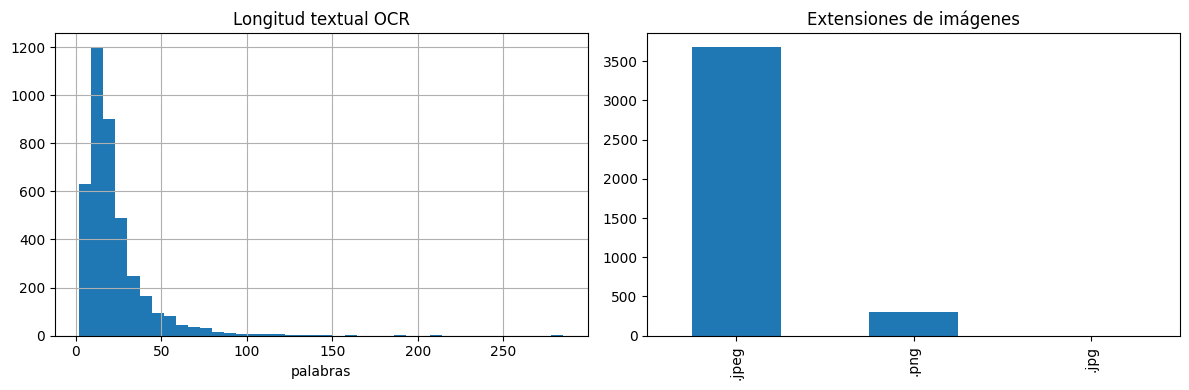

In [4]:
print("Train language distribution:", train_all_df["lang"].fillna("").replace("", "unknown").value_counts().to_dict())
print("Test language distribution:", test_df["lang"].fillna("").replace("", "unknown").value_counts().to_dict())
if "lang_source" in train_all_df.columns:
    print("Training language source:", train_all_df["lang_source"].fillna("unknown").value_counts().to_dict())
    print("Test language source:", test_df["lang_source"].fillna("unknown").value_counts().to_dict())
print("Train images found:", int(train_all_df["image_path"].astype(bool).sum()), "/", len(train_all_df))
print("Test images found:", int(test_df["image_path"].astype(bool).sum()), "/", len(test_df))
print("Empty training OCR texts:", int(train_all_df["text"].fillna("").str.len().eq(0).sum()))

display(train_all_df.groupby(["lang", "gold_2_1_hard"], dropna=False).size().rename("n").reset_index())
display(train_all_df.groupby(["lang", "gold_2_2_hard"], dropna=False).size().rename("n").reset_index())

facet_rows = []
for labels in train_all_df["gold_2_3_hard"].dropna():
    labels = labels if isinstance(labels, list) else [labels]
    for label in labels:
        facet_rows.append(label)
display(pd.Series(facet_rows).value_counts().rename_axis("label").reset_index(name="n"))

sensor_cols = [c for c in train_all_df.columns if c.startswith("sensorial_")]
print("Number of sensor features:", len(sensor_cols))
if sensor_cols:
    missing = train_all_df[sensor_cols].isna().mean().sort_values(ascending=False).head(20)
    display(missing.rename("missing_rate").reset_index().rename(columns={"index": "feature"}))

if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    train_all_df["text_words"].hist(ax=axes[0], bins=40)
    axes[0].set_title("Longitud textual OCR")
    axes[0].set_xlabel("palabras")
    pd.Series([Path(p).suffix.lower() for p in train_all_df["image_path"] if p]).value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title("Extensiones de imágenes")
    plt.tight_layout()

In [5]:
def get_sensor_columns(df):
    return [
        c for c in df.columns
        if (c.startswith("sensorial_") or c in {"lang_en", "lang_es"})
        and pd.api.types.is_numeric_dtype(df[c])
    ]


def sensor_matrices(train_df, dev_df, test_df):
    cols = get_sensor_columns(train_df)
    if not cols:
        return None, None, None, []
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    X_train = pipe.fit_transform(train_df[cols])
    X_dev = pipe.transform(dev_df[cols])
    X_test = pipe.transform(test_df[cols])
    return X_train, X_dev, X_test, cols


def ids_hash(ids):
    text = "|".join(map(str, ids))
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:12]


def make_sparse_preprocessor(representation="word_char", include_sensors=False):
    parts = []
    if representation in {"word", "word_char"}:
        parts.append(
            (
                "word",
                TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True),
                "model_text",
            )
        )
    if representation in {"char", "word_char"}:
        parts.append(
            (
                "char",
                TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True),
                "model_text",
            )
        )
    if include_sensors:
        sensor_cols = get_sensor_columns(train_all_df)
        if sensor_cols:
            parts.append(
                (
                    "sensors",
                    Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))]),
                    sensor_cols,
                )
            )
    return ColumnTransformer(parts, remainder="drop", sparse_threshold=0.40)


def align_proba_columns(proba, estimator_classes, label_names):
    proba = np.asarray(proba, dtype=float)
    aligned = np.zeros((proba.shape[0], len(label_names)), dtype=float)
    for j, cls in enumerate(estimator_classes):
        if int(cls) < len(label_names):
            aligned[:, int(cls)] = proba[:, j]
    row_sum = aligned.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return aligned / row_sum


def proba_from_estimator(estimator, X, label_names):
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        if isinstance(proba, list):
            if len(proba) == len(label_names) and proba[0].ndim == 2:
                return np.vstack([p[:, 1] for p in proba]).T
            proba = proba[0]
        classes = getattr(estimator, "classes_", np.arange(proba.shape[1]))
        return align_proba_columns(proba, classes, label_names)
    if hasattr(estimator, "decision_function"):
        scores = np.asarray(estimator.decision_function(X), dtype=float)
        if scores.ndim == 1:
            pos = expit(scores)
            return np.vstack([1 - pos, pos]).T
        return softmax(scores, axis=1)
    pred = estimator.predict(X)
    out = np.zeros((len(pred), len(label_names)), dtype=float)
    out[np.arange(len(pred)), pred.astype(int)] = 1.0
    return out


def fit_with_optional_weight(pipe, X, y, sample_weight=None):
    try:
        if sample_weight is not None:
            return pipe.fit(X, y, clf__sample_weight=sample_weight)
    except TypeError:
        pass
    return pipe.fit(X, y)


def optimize_binary_threshold(y_true, proba, positive_index=1):
    scores = np.asarray(proba)[:, positive_index]
    thresholds = np.unique(np.quantile(scores, np.linspace(0.02, 0.98, 97)))
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        pred = (scores >= t).astype(int)
        value = f1_score(y_true, pred, zero_division=0)
        if value > best_f1:
            best_t, best_f1 = float(t), float(value)
    return best_t, best_f1


OFFICIAL_METRIC_KEYS = ["icm", "icm_norm", "f1_official", "icm_soft", "icm_soft_norm", "cross_entropy"]
_OFFICIAL_METRIC_WARNINGS_SHOWN = set()


def normalize_task_id(task_id="2_1"):
    task_id = str(task_id or "2_1")
    return task_id[4:] if task_id.startswith("task") else task_id


def official_metric_values(metrics):
    return {key: metrics.get(key, np.nan) for key in OFFICIAL_METRIC_KEYS}


def _warn_official_metric_once(key, message):
    if key not in _OFFICIAL_METRIC_WARNINGS_SHOWN:
        print(message)
        _OFFICIAL_METRIC_WARNINGS_SHOWN.add(key)


def _safe_label_distribution(value, label_names, fallback_label=None, normalize=True):
    out = {label: 0.0 for label in label_names}
    if isinstance(value, dict):
        for label in label_names:
            try:
                val = float(value.get(label, 0.0))
            except Exception:
                val = 0.0
            out[label] = val if np.isfinite(val) and val > 0 else 0.0
    elif isinstance(value, (list, tuple, set)):
        labels = [label for label in value if label in out]
        if labels:
            weight = 1.0 / len(labels) if normalize else 1.0
            for label in labels:
                out[label] = weight
    elif value in out:
        out[value] = 1.0

    total = float(sum(out.values()))
    if total <= 0 and fallback_label in out:
        out[fallback_label] = 1.0
        total = 1.0
    if normalize and total > 0:
        out = {label: float(val / total) for label, val in out.items()}
    return out


def _write_pyevall_json(path, records):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)


def _extract_pyevall_metric(report, metric_name):
    try:
        metric = report.report["metrics"][metric_name]
        return float(metric["results"]["average_per_test_case"])
    except Exception:
        return np.nan


def compute_official_single_label_metrics(y_true, proba, pred, label_names, eval_df=None, task_id="2_1"):
    """Calcula m?tricas oficiales con PyEvALL sobre la validaci?n del modelo."""
    out = {key: np.nan for key in OFFICIAL_METRIC_KEYS}
    if PyEvALLEvaluation is None or MetricFactory is None or PyEvALLUtils is None:
        _warn_official_metric_once("pyevall_missing", "Aviso: PyEvALL no est? disponible; no se calculan ICM/ICM-Soft/Cross-Entropy.")
        return out

    task_id = normalize_task_id(task_id)
    test_case = f"task{task_id}"
    y_true = np.asarray(y_true)
    proba = np.nan_to_num(np.asarray(proba, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    if proba.ndim != 2 or proba.shape[1] != len(label_names):
        return out
    row_sum = proba.sum(axis=1, keepdims=True)
    row_sum[row_sum <= 0] = 1.0
    proba = np.clip(proba / row_sum, 0.0, 1.0)
    pred = np.asarray(pred, dtype=int)

    if eval_df is not None and "id_EXIST" in eval_df.columns and len(eval_df) == len(y_true):
        ids = [str(x) for x in eval_df["id_EXIST"].tolist()]
    else:
        ids = [str(i) for i in range(len(y_true))]

    hard_gold = []
    hard_pred = []
    soft_gold = []
    soft_pred = []
    soft_col = f"gold_{task_id}_soft"
    hard_col = f"gold_{task_id}_hard"

    for i, item_id in enumerate(ids):
        true_idx = int(y_true[i])
        pred_idx = int(pred[i])
        fallback_gold = label_names[true_idx]
        fallback_pred = label_names[pred_idx]
        hard_value = fallback_gold
        soft_value = None
        if eval_df is not None and len(eval_df) == len(y_true):
            if hard_col in eval_df.columns and pd.notna(eval_df.iloc[i].get(hard_col)):
                hard_value = eval_df.iloc[i].get(hard_col)
            if soft_col in eval_df.columns:
                soft_value = eval_df.iloc[i].get(soft_col)

        hard_gold.append({"test_case": test_case, "id": item_id, "value": str(hard_value)})
        hard_pred.append({"test_case": test_case, "id": item_id, "value": str(fallback_pred)})
        soft_gold.append({
            "test_case": test_case,
            "id": item_id,
            "value": _safe_label_distribution(soft_value, label_names, fallback_label=fallback_gold, normalize=True),
        })
        soft_pred.append({
            "test_case": test_case,
            "id": item_id,
            "value": {label: float(proba[i, j]) for j, label in enumerate(label_names)},
        })

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        hard_gold_path = tmpdir / "gold_hard.json"
        hard_pred_path = tmpdir / "pred_hard.json"
        soft_gold_path = tmpdir / "gold_soft.json"
        soft_pred_path = tmpdir / "pred_soft.json"
        _write_pyevall_json(hard_gold_path, hard_gold)
        _write_pyevall_json(hard_pred_path, hard_pred)
        _write_pyevall_json(soft_gold_path, soft_gold)
        _write_pyevall_json(soft_pred_path, soft_pred)

        try:
            report = PyEvALLEvaluation().evaluate(
                str(hard_pred_path),
                str(hard_gold_path),
                [MetricFactory.ICM.value, MetricFactory.ICMNorm.value, MetricFactory.FMeasure.value],
                report=PyEvALLUtils.PARAM_OPTION_REPORT_SIMPLE,
                log_level=PyEvALLUtils.PARAM_OPTION_LOG_LEVEL_NONE,
            )
            out["icm"] = _extract_pyevall_metric(report, MetricFactory.ICM.value)
            out["icm_norm"] = _extract_pyevall_metric(report, MetricFactory.ICMNorm.value)
            out["f1_official"] = _extract_pyevall_metric(report, MetricFactory.FMeasure.value)
        except Exception as exc:
            _warn_official_metric_once("pyevall_hard", f"Aviso: PyEvALL hard no pudo calcularse: {type(exc).__name__}: {exc}")

        try:
            report = PyEvALLEvaluation().evaluate(
                str(soft_pred_path),
                str(soft_gold_path),
                [MetricFactory.ICMSoft.value, MetricFactory.ICMSoftNorm.value, MetricFactory.CrossEntropy.value],
                report=PyEvALLUtils.PARAM_OPTION_REPORT_SIMPLE,
                log_level=PyEvALLUtils.PARAM_OPTION_LOG_LEVEL_NONE,
            )
            out["icm_soft"] = _extract_pyevall_metric(report, MetricFactory.ICMSoft.value)
            out["icm_soft_norm"] = _extract_pyevall_metric(report, MetricFactory.ICMSoftNorm.value)
            out["cross_entropy"] = _extract_pyevall_metric(report, MetricFactory.CrossEntropy.value)
        except Exception as exc:
            _warn_official_metric_once("pyevall_soft", f"Aviso: PyEvALL soft no pudo calcularse: {type(exc).__name__}: {exc}")

    return out


def evaluate_single_label(y_true, proba, label_names, positive_index=None, threshold=None, eval_df=None, task_id="2_1"):
    proba = np.asarray(proba, dtype=float)
    if positive_index is not None:
        if threshold is None:
            threshold, _ = optimize_binary_threshold(y_true, proba, positive_index)
        pred = (proba[:, positive_index] >= threshold).astype(int)
    else:
        pred = proba.argmax(axis=1)
        threshold = np.nan
    result = {
        "accuracy": accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "threshold": threshold,
        "report": classification_report(y_true, pred, target_names=label_names, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, pred),
        "pred": pred,
    }
    if positive_index is not None:
        p, r, f, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
        result.update({"positive_f1": f, "precision": p, "recall": r})
    if eval_df is not None:
        result.update(compute_official_single_label_metrics(y_true, proba, pred, label_names, eval_df=eval_df, task_id=task_id))
    return result


def postprocess_multilabel(scores, thresholds, label_names):
    scores = np.asarray(scores, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)
    pred = (scores >= thresholds.reshape(1, -1)).astype(int)
    if "NO" in label_names:
        no_idx = label_names.index("NO")
        facet_idx = [i for i, label in enumerate(label_names) if label != "NO"]
        facet_active = pred[:, facet_idx].sum(axis=1) > 0
        pred[facet_active, no_idx] = 0
        no_facet = ~facet_active
        pred[no_facet, :] = 0
        pred[no_facet, no_idx] = 1
    else:
        empty = pred.sum(axis=1) == 0
        pred[empty, np.argmax(scores[empty], axis=1)] = 1
    return pred


def optimize_multilabel_thresholds(y_true, scores, label_names):
    scores = np.asarray(scores, dtype=float)
    thresholds = np.full(scores.shape[1], 0.5, dtype=float)
    grid = np.linspace(0.10, 0.90, 33)
    for j in range(scores.shape[1]):
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            local = thresholds.copy()
            local[j] = t
            pred = postprocess_multilabel(scores, local, label_names)
            value = f1_score(y_true[:, j], pred[:, j], zero_division=0)
            if value > best_f1:
                best_t, best_f1 = float(t), float(value)
        thresholds[j] = best_t
    return thresholds


def evaluate_multilabel(y_true, scores, label_names, thresholds=None):
    if thresholds is None:
        thresholds = optimize_multilabel_thresholds(y_true, scores, label_names)
    pred = postprocess_multilabel(scores, thresholds, label_names)
    facet_idx = [i for i, label in enumerate(label_names) if label != "NO"]
    return {
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "micro_f1": f1_score(y_true, pred, average="micro", zero_division=0),
        "samples_f1": f1_score(y_true, pred, average="samples", zero_division=0),
        "facet_macro_f1": f1_score(y_true[:, facet_idx], pred[:, facet_idx], average="macro", zero_division=0),
        "thresholds": thresholds,
        "report": classification_report(y_true, pred, target_names=label_names, zero_division=0),
        "pred": pred,
    }

In [6]:
def _np_float32_2d(x, name="array"):
    """Convierte a matriz float32 2D y falla con mensaje claro si no se puede."""
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.ndim != 2:
        raise ValueError(f"{name} debe ser 2D, recibido shape={arr.shape}")
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def validate_embedding_triplet(X_train, X_dev, X_test, train_df, dev_df, test_df, name="embeddings"):
    """Valida filas y dimensiones para evitar errores de shape aguas abajo."""
    X_train = _np_float32_2d(X_train, f"{name}/train")
    X_dev = _np_float32_2d(X_dev, f"{name}/dev")
    X_test = _np_float32_2d(X_test, f"{name}/test")

    expected_rows = (len(train_df), len(dev_df), len(test_df))
    actual_rows = (X_train.shape[0], X_dev.shape[0], X_test.shape[0])
    if actual_rows != expected_rows:
        raise ValueError(f"{name}: filas incompatibles train/dev/test={actual_rows}; esperado={expected_rows}")

    dims = (X_train.shape[1], X_dev.shape[1], X_test.shape[1])
    if len(set(dims)) != 1:
        raise ValueError(f"{name}: dimensiones incompatibles train/dev/test={dims}")

    return X_train, X_dev, X_test


def cached_embedding_triplet_ok(paths, train_df, dev_df, test_df, name="embeddings", drive_paths=None):
    """Carga cache compatible priorizando local antes que persistente."""
    paths = [Path(p) for p in paths]
    drive_paths = [Path(p) for p in drive_paths] if drive_paths else None

    def _try_load(candidate_paths, source_label, delete_if_invalid=False):
        if not candidate_paths or not all(p.exists() for p in candidate_paths):
            return None
        try:
            triplet = [np.load(p) for p in candidate_paths]
            triplet = validate_embedding_triplet(*triplet, train_df, dev_df, test_df, name=name)
            print(f"Cache valida para {name} cargada desde {source_label}: {candidate_paths[0].parent}")
            return triplet
        except Exception as exc:
            print(f"Aviso: cache invalida para {name} en {source_label}; se ignora/regenera. Motivo: {exc}")
            if delete_if_invalid:
                for p in candidate_paths:
                    try:
                        p.unlink(missing_ok=True)
                    except Exception:
                        pass
            return None

    cached = _try_load(paths, "cache local rapida", delete_if_invalid=True)
    if cached is not None:
        return cached

    cached = _try_load(drive_paths, "cache persistente", delete_if_invalid=False)
    if cached is not None:
        for arr, dst in zip(cached, paths):
            dst.parent.mkdir(parents=True, exist_ok=True)
            np.save(dst, arr)
        print(f"Cache persistente compatible copiada a local rapido: {paths[0].parent}")
        return cached

    return None


def embedding_cache_paths(prefix, key):
    """Devuelve rutas train/dev/test para cache local y persistente."""
    splits = ["train", "dev", "test"]
    local_dir = Path(CACHE_DIR)
    local_dir.mkdir(parents=True, exist_ok=True)
    local_paths = [local_dir / f"{prefix}_{key}_{split}.npy" for split in splits]

    drive_dir = Path(globals().get("DRIVE_EMB_CACHE_DIR", PERSISTENT_CACHE_DIR / "embeddings"))
    drive_dir.mkdir(parents=True, exist_ok=True)
    drive_paths = None
    if drive_dir.resolve() != local_dir.resolve():
        drive_paths = [drive_dir / f"{prefix}_{key}_{split}.npy" for split in splits]

    return local_paths, drive_paths


def save_embedding_triplet(cache_paths, drive_cache_paths, X_train, X_dev, X_test, name="embeddings"):
    """Guarda embeddings en local rapido y en cache persistente."""
    arrays = [X_train, X_dev, X_test]
    for arr, dst in zip(arrays, cache_paths):
        dst = Path(dst)
        dst.parent.mkdir(parents=True, exist_ok=True)
        np.save(dst, arr)
    print(f"{name}: guardado en cache local rapida: {Path(cache_paths[0]).parent}")

    if drive_cache_paths:
        for arr, dst in zip(arrays, drive_cache_paths):
            dst = Path(dst)
            dst.parent.mkdir(parents=True, exist_ok=True)
            np.save(dst, arr)
        print(f"{name}: guardado tambien en cache persistente: {Path(drive_cache_paths[0]).parent}")


def local_image_cache_root():
    """Carpeta local rápida para copiar imágenes antes de pasarlas por CLIP/DINO."""
    root = Path("/content/exist2026_image_cache") if Path("/content").exists() else OUTPUT_DIR / "image_cache"
    root.mkdir(parents=True, exist_ok=True)
    return root


def _local_image_destination(src_path):
    src_path = Path(src_path)
    root = local_image_cache_root()
    try:
        rel = src_path.resolve().relative_to(DATA_ROOT.resolve())
        return root / rel
    except Exception:
        digest = hashlib.md5(str(src_path).encode("utf-8")).hexdigest()[:12]
        return root / f"{digest}_{src_path.name}"


def stage_images_to_local(*frames):
    """Copia imágenes de Drive a /content una sola vez y devuelve frames actualizados.

    Leer miles de ficheros pequeños directamente desde Google Drive suele ser el
    cuello de botella. Esta función mantiene la ruta original si el archivo ya es
    local y solo copia desde Drive cuando hace falta.
    """
    if not globals().get("USE_LOCAL_IMAGE_STAGING", True):
        return frames

    mapping = {}
    unique_paths = []
    for frame in frames:
        for value in frame.get("image_path", []):
            if not value:
                continue
            src = Path(value)
            if src.exists() and src.is_file() and str(src).startswith("/content/drive"):
                key = str(src)
                if key not in mapping:
                    mapping[key] = key
                    unique_paths.append(src)

    if not unique_paths:
        return frames

    copied = reused = failed = 0
    for idx, src in enumerate(unique_paths, start=1):
        dst = _local_image_destination(src)
        try:
            dst.parent.mkdir(parents=True, exist_ok=True)
            if dst.exists() and dst.stat().st_size == src.stat().st_size:
                reused += 1
            else:
                import shutil
                shutil.copy2(src, dst)
                copied += 1
            mapping[str(src)] = str(dst)
        except Exception as exc:
            failed += 1
            mapping[str(src)] = str(src)
            if failed <= 5:
                print(f"Aviso: no se pudo copiar imagen a local: {src} | {exc}")
        if idx % 500 == 0:
            print(f"Staging imágenes local: {idx}/{len(unique_paths)} procesadas...")

    print(
        "Staging imágenes local completado:",
        f"copiadas={copied}, reutilizadas={reused}, fallidas={failed}, destino={local_image_cache_root()}"
    )

    staged_frames = []
    for frame in frames:
        staged = frame.copy()
        staged["image_path"] = staged["image_path"].map(lambda x: mapping.get(str(x), x) if x else x)
        staged_frames.append(staged)
    return tuple(staged_frames)


def safe_linear_projection(layer, tensor, layer_name="projection"):
    """Apply a Linear projection only when the tensor has the expected input size."""
    if layer is None:
        return tensor
    if not isinstance(tensor, torch.Tensor):
        raise TypeError(f"{layer_name}: se esperaba torch.Tensor, recibido {type(tensor)}")

    in_features = int(getattr(layer, "in_features", -1))
    out_features = int(getattr(layer, "out_features", -1))
    weight = getattr(layer, "weight", None)
    if weight is not None and hasattr(weight, "shape") and len(weight.shape) == 2:
        out_features = out_features if out_features > 0 else int(weight.shape[0])
        in_features = in_features if in_features > 0 else int(weight.shape[1])

    last_dim = int(tensor.shape[-1])
    if out_features > 0 and last_dim == out_features:
        return tensor
    if in_features > 0 and last_dim == in_features:
        return layer(tensor)

    raise RuntimeError(
        f"{layer_name}: dimensi?n incompatible. Tensor={tuple(tensor.shape)}, "
        f"Linear espera in_features={in_features}, out_features={out_features}."
    )


def pooled_tensor_from_output(outputs, prefer_image_embeds=True):
    """Extrae de forma robusta un tensor 2D desde salidas de HF/CLIP."""
    if isinstance(outputs, torch.Tensor):
        tensor = outputs
    elif prefer_image_embeds and hasattr(outputs, "image_embeds") and outputs.image_embeds is not None:
        tensor = outputs.image_embeds
    elif hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        tensor = outputs.pooler_output
    elif hasattr(outputs, "last_hidden_state") and outputs.last_hidden_state is not None:
        tensor = outputs.last_hidden_state[:, 0]
    elif isinstance(outputs, (tuple, list)) and outputs:
        tensor = outputs[0]
        if isinstance(tensor, torch.Tensor) and tensor.ndim == 3:
            tensor = tensor[:, 0]
    else:
        raise TypeError(f"No se pudo extraer un tensor de salida de tipo {type(outputs)}")

    if tensor.ndim == 3:
        tensor = tensor[:, 0]
    if tensor.ndim != 2:
        raise ValueError(f"Tensor de embeddings debe ser 2D, recibido shape={tuple(tensor.shape)}")
    return tensor


def encode_sentence_model(model_name, train_df, dev_df, test_df):
    from sentence_transformers import SentenceTransformer

    key = f"{slug(model_name)}_{ids_hash(train_df.id_EXIST)}_{ids_hash(dev_df.id_EXIST)}_{ids_hash(test_df.id_EXIST)}"
    cache_paths, drive_cache_paths = embedding_cache_paths("sent", key)
    train_cache, dev_cache, test_cache = cache_paths

    cached = cached_embedding_triplet_ok(
        cache_paths, train_df, dev_df, test_df, name=f"sent:{model_name}", drive_paths=drive_cache_paths
    )
    if cached is not None:
        return cached

    model = SentenceTransformer(model_name, device=DEVICE)

    def prep(texts):
        if "e5" in model_name.lower():
            return [f"query: {text}" for text in texts]
        return list(map(str, texts))

    X_train = model.encode(prep(train_df["model_text"]), batch_size=TEXT_EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True)
    X_dev = model.encode(prep(dev_df["model_text"]), batch_size=TEXT_EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True)
    X_test = model.encode(prep(test_df["model_text"]), batch_size=TEXT_EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True)
    X_train, X_dev, X_test = validate_embedding_triplet(X_train, X_dev, X_test, train_df, dev_df, test_df, name=f"sent:{model_name}")

    save_embedding_triplet(cache_paths, drive_cache_paths, X_train, X_dev, X_test, name=f"sent:{model_name}")
    return X_train, X_dev, X_test



def encode_image_model(model_name, train_df, dev_df, test_df):
    """Genera embeddings de imagen de forma robusta.

    Corrige fallos de shape como:
    RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x512 and 768x512)

    El problema aparece cuando CLIP devuelve un vector ya proyectado de 512
    dimensiones y el código vuelve a aplicar `visual_projection`, que espera 768.
    La función `safe_linear_projection` comprueba las dimensiones antes de aplicar
    la capa y evita la doble proyección.
    """
    if torch is None:
        print("PyTorch no disponible; se omiten embeddings de imagen.")
        return None, None, None

    from PIL import Image

    key = f"{slug(model_name)}_{ids_hash(train_df.id_EXIST)}_{ids_hash(dev_df.id_EXIST)}_{ids_hash(test_df.id_EXIST)}"
    cache_paths, drive_cache_paths = embedding_cache_paths("img", key)
    train_cache, dev_cache, test_cache = cache_paths

    cached = cached_embedding_triplet_ok(
        cache_paths, train_df, dev_df, test_df, name=f"img:{model_name}", drive_paths=drive_cache_paths
    )
    if cached is not None:
        return cached

    # Importante para velocidad: si las imágenes están en Drive, se copian una
    # vez a /content y el modelo lee desde disco local rápido.
    train_img_df, dev_img_df, test_img_df = stage_images_to_local(train_df, dev_df, test_df)

    all_paths = list(train_img_df["image_path"]) + list(dev_img_df["image_path"]) + list(test_img_df["image_path"])
    missing = sum(not bool(p) or not Path(p).exists() for p in all_paths)
    if missing:
        print(f"Aviso: faltan {missing}/{len(all_paths)} imágenes; se usarán vectores cero para esas filas.")

    model_name_lower = model_name.lower()

    if "clip" in model_name_lower:
        try:
            processor = CLIPProcessor.from_pretrained(model_name, use_fast=False)
        except TypeError:
            processor = CLIPProcessor.from_pretrained(model_name)

        model = CLIPModel.from_pretrained(model_name).to(DEVICE)
        fallback_output_dim = int(getattr(model.config, "projection_dim", 512))

        def encode_batch(images):
            inputs = processor(images=images, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

            with torch.no_grad():
                pixel_values = inputs["pixel_values"]

                # No usamos model.get_image_features() porque en algunas combinaciones
                # de transformers/CLIP esa función puede devolver o recibir tensores ya
                # proyectados de 512 dimensiones y volver a aplicar visual_projection
                # produce: mat1 and mat2 shapes cannot be multiplied (32x512 and 768x512).
                # Esta ruta manual toma la salida visual y proyecta solo si la dimensión
                # coincide con in_features; si ya está en projection_dim, la deja intacta.
                vision_outputs = model.vision_model(pixel_values=pixel_values)
                pooled = pooled_tensor_from_output(vision_outputs, prefer_image_embeds=False)
                feats = safe_linear_projection(
                    getattr(model, "visual_projection", None), pooled, "CLIP visual_projection"
                )
                feats = torch.nn.functional.normalize(feats, p=2, dim=-1)

            return feats.detach().cpu().numpy().astype(np.float32)

    else:
        processor = AutoImageProcessor.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(DEVICE)
        fallback_output_dim = int(getattr(model.config, "hidden_size", 768))

        def encode_batch(images):
            inputs = processor(images=images, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = model(**inputs)
                feats = pooled_tensor_from_output(outputs, prefer_image_embeds=False)
                feats = torch.nn.functional.normalize(feats, p=2, dim=-1)

            return feats.detach().cpu().numpy().astype(np.float32)

    model.eval()

    def encode_frame(frame, batch_size=IMAGE_EMBED_BATCH_SIZE):
        output = None
        feature_dim = None
        pending_images = []
        pending_positions = []

        def flush_batch():
            nonlocal output, feature_dim, pending_images, pending_positions
            if not pending_images:
                return
            batch_features = _np_float32_2d(encode_batch(pending_images), name=f"img:{model_name}/batch")
            current_dim = int(batch_features.shape[1])
            if feature_dim is None:
                feature_dim = current_dim
                output = np.zeros((len(frame), feature_dim), dtype=np.float32)
            elif current_dim != feature_dim:
                raise RuntimeError(
                    f"img:{model_name}: dimensión de batch incompatible: {current_dim} != {feature_dim}"
                )
            output[np.asarray(pending_positions, dtype=int)] = batch_features
            pending_images, pending_positions = [], []

        for i, path_value in enumerate(frame["image_path"]):
            path = Path(path_value) if path_value else None
            if path is None or not path.exists() or not path.is_file():
                continue

            try:
                with Image.open(path) as img:
                    pending_images.append(img.convert("RGB").copy())
                pending_positions.append(i)
            except Exception as exc:
                print(f"No se pudo leer imagen: {path} | {exc}")
                continue

            if len(pending_images) == batch_size:
                flush_batch()

        flush_batch()

        if output is None:
            output = np.zeros((len(frame), fallback_output_dim), dtype=np.float32)
        return output

    X_train = encode_frame(train_img_df)
    X_dev = encode_frame(dev_img_df)
    X_test = encode_frame(test_img_df)
    X_train, X_dev, X_test = validate_embedding_triplet(X_train, X_dev, X_test, train_df, dev_df, test_df, name=f"img:{model_name}")

    save_embedding_triplet(cache_paths, drive_cache_paths, X_train, X_dev, X_test, name=f"img:{model_name}")

    del model
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

    return X_train, X_dev, X_test



def build_dense_fusion(train_df, dev_df, test_df, modality, text_model=None, image_model=None):
    blocks_train, blocks_dev, blocks_test = [], [], []
    if "text" in modality:
        Xtr, Xdv, Xte = encode_sentence_model(text_model, train_df, dev_df, test_df)
        Xtr, Xdv, Xte = validate_embedding_triplet(Xtr, Xdv, Xte, train_df, dev_df, test_df, name=f"text:{text_model}")
        blocks_train.append(Xtr)
        blocks_dev.append(Xdv)
        blocks_test.append(Xte)
    if "image" in modality:
        Xtr, Xdv, Xte = encode_image_model(image_model, train_df, dev_df, test_df)
        if Xtr is None:
            return None, None, None
        Xtr, Xdv, Xte = validate_embedding_triplet(Xtr, Xdv, Xte, train_df, dev_df, test_df, name=f"image:{image_model}")
        blocks_train.append(Xtr)
        blocks_dev.append(Xdv)
        blocks_test.append(Xte)
    if "sensor" in modality:
        Xtr, Xdv, Xte, sensor_cols = sensor_matrices(train_df, dev_df, test_df)
        if Xtr is not None:
            Xtr, Xdv, Xte = validate_embedding_triplet(Xtr, Xdv, Xte, train_df, dev_df, test_df, name="sensors")
            blocks_train.append(Xtr)
            blocks_dev.append(Xdv)
            blocks_test.append(Xte)
    if not blocks_train:
        return None, None, None

    X_train = np.hstack(blocks_train).astype(np.float32)
    X_dev = np.hstack(blocks_dev).astype(np.float32)
    X_test = np.hstack(blocks_test).astype(np.float32)
    return validate_embedding_triplet(X_train, X_dev, X_test, train_df, dev_df, test_df, name=f"fusion:{modality}")


In [7]:
def single_label_model_configs(n_classes):
    configs = [
        ("lr_c1", LogisticRegression(max_iter=4000, C=1.0, class_weight="balanced", solver="liblinear" if n_classes == 2 else "lbfgs", random_state=SEED)),
        ("lr_c3", LogisticRegression(max_iter=4000, C=3.0, class_weight="balanced", solver="liblinear" if n_classes == 2 else "lbfgs", random_state=SEED)),
        ("sgd_log", SGDClassifier(loss="log_loss", alpha=1e-5, class_weight="balanced", max_iter=2500, random_state=SEED)),
        ("linear_svc", LinearSVC(C=1.0, class_weight="balanced", random_state=SEED)),
    ]
    if RUN_HEAVY_TREE_MODELS:
        configs.extend([
            ("extra_trees", ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1)),
            ("random_forest", RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=SEED, n_jobs=-1)),
        ])
        if LGBMClassifier is not None:
            configs.append(("lightgbm", LGBMClassifier(n_estimators=500, learning_rate=0.03, class_weight="balanced", random_state=SEED, verbosity=-1)))
        if XGBClassifier is not None:
            objective = "binary:logistic" if n_classes == 2 else "multi:softprob"
            configs.append(("xgboost", XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=4, objective=objective, random_state=SEED, eval_metric="logloss")))
    return configs


def run_sparse_single_label(train_df, dev_df, test_df, y_train, y_dev, label_names, positive_index=None, output_prefix="task"):
    rows, bank = [], {}
    n_classes = len(label_names)
    configs = []
    for rep in ["word", "char", "word_char"]:
        configs.extend([
            (f"text_{rep}_multinomial_nb", rep, False, MultinomialNB(alpha=0.25), False),
            (f"text_{rep}_complement_nb", rep, False, ComplementNB(alpha=0.50), False),
            (f"text_{rep}_lr_c2", rep, False, LogisticRegression(max_iter=4000, C=2.0, class_weight="balanced", solver="liblinear" if n_classes == 2 else "lbfgs", random_state=SEED), False),
            (f"text_{rep}_linear_svc", rep, False, LinearSVC(C=1.0, class_weight="balanced", random_state=SEED), False),
        ])
    for rep in ["word", "char", "word_char"]:
        configs.extend([
            (f"text_sensor_{rep}_lr_c2", rep, True, LogisticRegression(max_iter=4000, C=2.0, class_weight="balanced", solver="liblinear" if n_classes == 2 else "lbfgs", random_state=SEED), False),
            (f"text_sensor_{rep}_sgd_log", rep, True, SGDClassifier(loss="log_loss", alpha=1e-5, class_weight="balanced", max_iter=2500, random_state=SEED), False),
        ])
    if RUN_HEAVY_TREE_MODELS:
        configs.extend([
            ("text_word_char_svd_extra_trees", "word_char", False, ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1), True),
            ("text_sensor_word_char_svd_extra_trees", "word_char", True, ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1), True),
        ])
    if QUICK_DEBUG:
        configs = configs[:5]

    for name, rep, include_sensors, clf, use_svd in configs:
        start = time.time()
        steps = [("prep", make_sparse_preprocessor(rep, include_sensors))]
        if use_svd:
            steps.extend([("svd", TruncatedSVD(n_components=256, random_state=SEED)), ("scale", StandardScaler())])
        steps.append(("clf", clf))
        pipe = Pipeline(steps)
        pipe.fit(train_df, y_train)
        dev_proba = proba_from_estimator(pipe, dev_df, label_names)
        test_proba = proba_from_estimator(pipe, test_df, label_names)
        metrics = evaluate_single_label(y_dev, dev_proba, label_names, positive_index=positive_index, eval_df=dev_df, task_id=output_prefix)
        row = {
            "model": name,
            "modality": "text+sensors" if include_sensors else "text",
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "accuracy": metrics["accuracy"],
            "positive_f1": metrics.get("positive_f1", np.nan),
            "threshold": metrics["threshold"],
            "runtime_seconds": round(time.time() - start, 2),
        }
        row.update(official_metric_values(metrics))
        rows.append(row)
        bank[name] = {"dev": dev_proba, "test": test_proba, "threshold": metrics["threshold"], "modality": "text+sensors" if include_sensors else "text"}
    result = pd.DataFrame(rows)
    metric = "positive_f1" if positive_index is not None else "macro_f1"
    result = result.sort_values(metric, ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_sparse_results.csv", index=False)
    return result, bank


def run_dense_single_label(train_df, dev_df, test_df, y_train, y_dev, label_names, positive_index=None, output_prefix="task"):
    if not RUN_DENSE_EMBEDDINGS:
        print("RUN_DENSE_EMBEDDINGS=False; se omiten embeddings densos.")
        return pd.DataFrame(), {}

    try:
        from tqdm.auto import tqdm
    except Exception:
        tqdm = lambda x, **kwargs: x

    text_models = [
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "intfloat/multilingual-e5-base",
    ]
    if FULL_MODULAR and not QUICK_DEBUG:
        text_models.append("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

    image_models = ["openai/clip-vit-base-patch32"]
    if RUN_HEAVY_DINO:
        image_models.append("facebook/dinov2-base")

    modality_specs = []
    for tm in text_models:
        modality_specs.append(("text", tm, None))
        modality_specs.append(("text+sensor", tm, None))
    if RUN_IMAGE_EMBEDDINGS:
        for im in image_models:
            modality_specs.append(("image", None, im))
            for tm in text_models[:2]:
                modality_specs.append(("text+image", tm, im))
                modality_specs.append(("text+image+sensor", tm, im))
    if QUICK_DEBUG:
        modality_specs = modality_specs[:4]

    rows, bank = [], {}
    failed_runs = []
    metric = "positive_f1" if positive_index is not None else "macro_f1"

    for modality, text_model, image_model in tqdm(modality_specs, desc="Dense modalities"):
        print("\n" + "=" * 100)
        print(f"Dense modality: {modality}")
        print(f"Text model: {text_model}")
        print(f"Image model: {image_model}")
        start_modality = time.time()

        try:
            X_train, X_dev, X_test = build_dense_fusion(train_df, dev_df, test_df, modality, text_model, image_model)
            if X_train is None:
                print("Saltado: no se pudieron generar embeddings.")
                continue
            X_train, X_dev, X_test = validate_embedding_triplet(
                X_train, X_dev, X_test, train_df, dev_df, test_df, name=f"run_dense:{modality}"
            )
        except Exception as exc:
            failed_runs.append({
                "stage": "embeddings",
                "modality": modality,
                "text_model": text_model or "",
                "image_model": image_model or "",
                "classifier": "",
                "error_type": type(exc).__name__,
                "error": str(exc),
            })
            print(f"Saltado por error de embeddings ({type(exc).__name__}): {exc}")
            continue

        print("Embeddings generados:")
        print(f"  X_train: {X_train.shape}")
        print(f"  X_dev:   {X_dev.shape}")
        print(f"  X_test:  {X_test.shape}")

        for clf_name, clf in tqdm(single_label_model_configs(len(label_names)), desc=f"Classifiers {modality}", leave=False):
            start = time.time()
            print(f"Entrenando clasificador: {clf_name}")
            try:
                local_clf = clone(clf)
                local_clf.fit(X_train, y_train)
                dev_proba = proba_from_estimator(local_clf, X_dev, label_names)
                test_proba = proba_from_estimator(local_clf, X_test, label_names)
                dev_proba = _np_float32_2d(dev_proba, name=f"{clf_name}/dev_proba")
                test_proba = _np_float32_2d(test_proba, name=f"{clf_name}/test_proba")
                if dev_proba.shape != (len(dev_df), len(label_names)):
                    raise ValueError(f"dev_proba shape={dev_proba.shape}; esperado={(len(dev_df), len(label_names))}")
                if test_proba.shape != (len(test_df), len(label_names)):
                    raise ValueError(f"test_proba shape={test_proba.shape}; esperado={(len(test_df), len(label_names))}")
                metrics = evaluate_single_label(y_dev, dev_proba, label_names, positive_index=positive_index, eval_df=dev_df, task_id=output_prefix)
            except Exception as exc:
                failed_runs.append({
                    "stage": "classifier",
                    "modality": modality,
                    "text_model": text_model or "",
                    "image_model": image_model or "",
                    "classifier": clf_name,
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                })
                print(f"Saltado clasificador {clf_name} por {type(exc).__name__}: {exc}")
                continue

            run_name = f"{modality}_{slug(text_model or 'no_text')}_{slug(image_model or 'no_image')}_{clf_name}"
            row = {
                "model": run_name,
                "modality": modality.replace("sensor", "sensors"),
                "text_model": text_model or "",
                "image_model": image_model or "",
                "classifier": clf_name,
                "macro_f1": metrics["macro_f1"],
                "weighted_f1": metrics["weighted_f1"],
                "accuracy": metrics["accuracy"],
                "positive_f1": metrics.get("positive_f1", np.nan),
                "threshold": metrics["threshold"],
                "runtime_seconds": round(time.time() - start, 2),
            }
            row.update(official_metric_values(metrics))
            rows.append(row)
            bank[run_name] = {
                "dev": dev_proba,
                "test": test_proba,
                "threshold": metrics["threshold"],
                "modality": modality.replace("sensor", "sensors"),
            }
            print(
                f"Finished {clf_name} | macro_f1={row['macro_f1']:.4f} | "
                f"weighted_f1={row['weighted_f1']:.4f} | accuracy={row['accuracy']:.4f} | "
                f"positive_f1={row['positive_f1']:.4f} | time={row['runtime_seconds']}s"
            )

        print(f"Modalidad terminada: {modality} | tiempo total={round(time.time() - start_modality, 2)}s")
        if rows:
            partial = pd.DataFrame(rows).sort_values(metric, ascending=False).reset_index(drop=True)
            print("Mejores resultados parciales:")
            display(partial.head(10))

    result = pd.DataFrame(rows)
    if failed_runs:
        failed = pd.DataFrame(failed_runs)
        failed_path = OUTPUT_DIR / f"{output_prefix}_dense_failed_runs.csv"
        failed.to_csv(failed_path, index=False)
        print(f"Aviso: {len(failed_runs)} combinaciones se saltaron y quedaron registradas en {failed_path}")
        display(failed.tail(20))

    if result.empty:
        print("No se ha generado ningún resultado dense.")
        return result, bank

    result = result.sort_values(metric, ascending=False).reset_index(drop=True)
    print("\nResultados finales dense:")
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_dense_multimodal_results.csv", index=False)
    return result, bank
def ensemble_single_label(y_dev, label_names, banks, positive_index=None, output_prefix="task", eval_df=None, task_id=None):
    merged = {name: value for bank in banks for name, value in bank.items()}
    if len(merged) < 2:
        print("No hay suficientes modelos para ensemble.")
        return None, None, None
    class_prior = np.bincount(y_dev, minlength=len(label_names)).astype(float)
    class_prior = class_prior / class_prior.sum()

    def fill_missing_proba(proba):
        proba = np.asarray(proba, dtype=float).copy()
        bad_rows = ~np.isfinite(proba).all(axis=1)
        if bad_rows.any():
            proba[bad_rows] = class_prior
        row_sum = proba.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        return proba / row_sum

    rows = []
    for name, value in merged.items():
        dev_proba = np.asarray(value["dev"], dtype=float)
        coverage_mask = np.isfinite(dev_proba).all(axis=1)
        if coverage_mask.sum() < max(10, len(y_dev) // 10):
            continue
        local_eval_df = eval_df.iloc[np.asarray(coverage_mask)].reset_index(drop=True) if eval_df is not None and len(eval_df) == len(y_dev) else None
        metrics = evaluate_single_label(
            y_dev[coverage_mask],
            dev_proba[coverage_mask],
            label_names,
            positive_index=positive_index,
            threshold=value.get("threshold"),
            eval_df=local_eval_df,
            task_id=task_id or output_prefix,
        )
        row = {
            "model": name,
            "modality": value.get("modality", ""),
            "macro_f1": metrics["macro_f1"],
            "positive_f1": metrics.get("positive_f1", np.nan),
            "threshold": metrics["threshold"],
            "coverage": float(coverage_mask.mean()),
        }
        row.update(official_metric_values(metrics))
        rows.append(row)
    if not rows:
        print("No hay vectores de probabilidad con cobertura suficiente para ensemble.")
        return None, None, None
    rank = pd.DataFrame(rows)
    metric = "positive_f1" if positive_index is not None else "macro_f1"
    rank = rank.sort_values([metric, "coverage"], ascending=[False, False]).reset_index(drop=True)
    display(rank.head(20))

    # Late fusion: media simple de los mejores. El stacking entrenado en el mismo dev
    # es optimista, así que se muestra solo como diagnóstico y no decide la salida final.
    top_names = rank.head(min(8, len(rank)))["model"].tolist()
    dev_stack = np.stack([fill_missing_proba(merged[n]["dev"]) for n in top_names], axis=0)
    test_stack = np.stack([fill_missing_proba(merged[n]["test"]) for n in top_names], axis=0)
    avg_dev = np.nanmean(dev_stack, axis=0)
    avg_test = np.nanmean(test_stack, axis=0)
    avg_metrics = evaluate_single_label(y_dev, avg_dev, label_names, positive_index=positive_index, eval_df=eval_df, task_id=task_id or output_prefix)

    meta_X_dev = np.hstack([merged[n]["dev"] for n in top_names])
    meta_X_test = np.hstack([merged[n]["test"] for n in top_names])
    meta_X_dev = np.nan_to_num(meta_X_dev, nan=0.0)
    meta_X_test = np.nan_to_num(meta_X_test, nan=0.0)
    meta = LogisticRegression(max_iter=3000, C=1.0, class_weight="balanced", solver="liblinear" if len(label_names) == 2 else "lbfgs", random_state=SEED)
    meta.fit(meta_X_dev, y_dev)
    stack_dev = proba_from_estimator(meta, meta_X_dev, label_names)
    stack_metrics = evaluate_single_label(y_dev, stack_dev, label_names, positive_index=positive_index, eval_df=eval_df, task_id=task_id or output_prefix)

    print("Late fusion top models:", top_names)
    print("Soft vote report:")
    print(avg_metrics["report"])
    print("Diagnostic stacking trained on development data; not an official metric:")
    print(stack_metrics["report"])
    return avg_dev, avg_test, avg_metrics

In [8]:
def _np_float32_2d(x, name="array"):
    """Convierte a matriz float32 2D y falla con mensaje claro si no se puede."""
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.ndim != 2:
        raise ValueError(f"{name} debe ser 2D, recibido shape={arr.shape}")
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=192, multilabel=False):
        self.texts = list(map(str, texts))
        self.labels = None if labels is None else np.asarray(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.multilabel = multilabel

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = self.tokenizer(self.texts[idx], truncation=True, max_length=self.max_length)
        if self.labels is not None:
            item["labels"] = self.labels[idx].astype(np.float32) if self.multilabel else int(self.labels[idx])
        return item


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, pos_weight=None, multilabel=False, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.pos_weight = pos_weight
        self.multilabel = multilabel

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.multilabel:
            labels = labels.to(device=logits.device, dtype=logits.dtype)
            pos_weight = self.pos_weight.to(device=logits.device, dtype=logits.dtype) if self.pos_weight is not None else None
            loss = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, labels)
        else:
            labels = labels.to(device=logits.device)
            weights = self.class_weights.to(device=logits.device, dtype=logits.dtype) if self.class_weights is not None else None
            loss = torch.nn.CrossEntropyLoss(weight=weights, label_smoothing=0.03)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def training_args(output_dir, metric_name, epochs=4, lr=2e-5):
    import inspect
    kwargs = dict(
        output_dir=str(output_dir),
        overwrite_output_dir=True,
        num_train_epochs=epochs,
        learning_rate=lr,
        per_device_train_batch_size=TRANSFORMER_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=TRANSFORMER_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=TRANSFORMER_GRAD_ACCUM_STEPS,
        weight_decay=0.01,
        logging_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model=metric_name,
        greater_is_better=True,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
        fp16=bool(USE_MIXED_PRECISION and DEVICE == "cuda"),
        dataloader_num_workers=0,
        dataloader_pin_memory=bool(DEVICE == "cuda"),
        remove_unused_columns=True,
    )
    sig = inspect.signature(TrainingArguments.__init__)
    kwargs["eval_strategy" if "eval_strategy" in sig.parameters else "evaluation_strategy"] = "epoch"
    kwargs = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return TrainingArguments(**kwargs)


def trainer_tokenizer_kwargs(tokenizer):
    import inspect
    params = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in params:
        return {"processing_class": tokenizer}
    if "tokenizer" in params:
        return {"tokenizer": tokenizer}
    return {}


def transformer_candidates(task_kind):
    base = [
        {"scope": "all", "model": "FacebookAI/xlm-roberta-base", "epochs": 5, "lr": 2e-5},
        {"scope": "all", "model": "microsoft/mdeberta-v3-base", "epochs": 5, "lr": 2e-5},
        {"scope": "en", "model": "cardiffnlp/twitter-roberta-base-offensive", "epochs": 5, "lr": 2e-5},
        {"scope": "es", "model": "dccuchile/bert-base-spanish-wwm-cased", "epochs": 5, "lr": 2e-5},
    ]
    if QUICK_DEBUG:
        return base[:1]
    if FULL_MODULAR:
        base.extend([
            {"scope": "en", "model": "roberta-base", "epochs": 5, "lr": 1.5e-5},
            {"scope": "es", "model": "dccuchile/bert-base-spanish-wwm-uncased", "epochs": 5, "lr": 2e-5},
        ])
    return base



def language_mask(df, scope):
    """Máscara robusta para seleccionar idioma en train/dev/test."""
    if scope == "all":
        return np.ones(len(df), dtype=bool)
    if "lang" not in df.columns:
        return np.zeros(len(df), dtype=bool)
    return df["lang"].fillna("").astype(str).str.lower().eq(scope).to_numpy()


def save_trainer_history(trainer, output_dir):
    history = pd.DataFrame(trainer.state.log_history)
    if history.empty:
        return history
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    history_path = output_dir / "training_history.csv"
    history.to_csv(history_path, index=False)
    metric_cols = [c for c in ["epoch", "loss", "eval_loss", "eval_macro_f1", "eval_positive_f1", "eval_accuracy", "learning_rate"] if c in history.columns]
    if metric_cols:
        print("Historial de entrenamiento:")
        display(history[metric_cols].dropna(how="all").tail(20))
    print("Training history saved:", history_path)
    return history


def record_transformer_failure(failed_runs, stage, run_name, scope, hf_model, exc):
    """Registra una combinación fallida de transformer sin parar el notebook."""
    failed_runs.append({
        "stage": stage,
        "model": run_name,
        "modality": "text_transformer",
        "scope": scope,
        "hf_model": hf_model,
        "error_type": type(exc).__name__,
        "error": str(exc),
    })
    print(f"Saltado {run_name} en stage={stage} por {type(exc).__name__}: {exc}")


def save_transformer_failures(failed_runs, output_prefix="task"):
    """Guarda los fallos de transformers en CSV y elimina registros obsoletos."""
    failed_path = OUTPUT_DIR / f"{output_prefix}_transformer_failed_runs.csv"
    if not failed_runs:
        failed_path.unlink(missing_ok=True)
        return None
    failed = pd.DataFrame(failed_runs)
    failed.to_csv(failed_path, index=False)
    print(f"Aviso: {len(failed_runs)} transformers se saltaron y quedaron registrados en {failed_path}")
    display(failed.tail(20))
    return failed_path


def cleanup_transformer_objects(*objects):
    """Libera memoria después de cada combinación de transformer."""
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()


def validate_transformer_single_outputs(dev_local, test_local, dv_mask, te_mask, dev_df, test_df, label_names, run_name):
    """Valida probabilidades single-label para evitar fallos de shape aguas abajo."""
    dev_local = _np_float32_2d(dev_local, name=f"{run_name}/dev_local")
    expected_dev = (int(np.asarray(dv_mask).sum()), len(label_names))
    if dev_local.shape != expected_dev:
        raise ValueError(f"{run_name}: dev_local shape={dev_local.shape}; esperado={expected_dev}")

    if test_local is not None:
        test_local = _np_float32_2d(test_local, name=f"{run_name}/test_local")
        expected_test = (int(np.asarray(te_mask).sum()), len(label_names))
        if test_local.shape != expected_test:
            raise ValueError(f"{run_name}: test_local shape={test_local.shape}; esperado={expected_test}")

    dev_proba = np.full((len(dev_df), len(label_names)), np.nan, dtype=np.float32)
    test_proba = np.full((len(test_df), len(label_names)), np.nan, dtype=np.float32)
    dev_proba[dv_mask] = dev_local
    if test_local is not None:
        test_proba[te_mask] = test_local
    return dev_proba, test_proba, dev_local


def validate_transformer_multilabel_outputs(dev_local, test_local, dv_mask, te_mask, dev_df, test_df, label_names, run_name):
    """Valida scores multilabel para evitar fallos de shape aguas abajo."""
    dev_local = _np_float32_2d(dev_local, name=f"{run_name}/dev_local")
    expected_dev = (int(np.asarray(dv_mask).sum()), len(label_names))
    if dev_local.shape != expected_dev:
        raise ValueError(f"{run_name}: dev_local shape={dev_local.shape}; esperado={expected_dev}")

    if test_local is not None:
        test_local = _np_float32_2d(test_local, name=f"{run_name}/test_local")
        expected_test = (int(np.asarray(te_mask).sum()), len(label_names))
        if test_local.shape != expected_test:
            raise ValueError(f"{run_name}: test_local shape={test_local.shape}; esperado={expected_test}")

    dev_scores = np.full((len(dev_df), len(label_names)), np.nan, dtype=np.float32)
    test_scores = np.full((len(test_df), len(label_names)), np.nan, dtype=np.float32)
    dev_scores[dv_mask] = dev_local
    if test_local is not None:
        test_scores[te_mask] = test_local
    return dev_scores, test_scores, dev_local


def run_transformer_single_label(train_df, dev_df, test_df, y_train_all, y_dev_all, label_names, positive_index=None, output_prefix="task"):
    if not RUN_TRANSFORMERS or torch is None or DEVICE != "cuda":
        print("Transformers omitidos. En Colab GPU, RUN_TRANSFORMERS=True.")
        return pd.DataFrame(), {}

    rows, bank, failed_runs = [], {}, []
    metric = "positive_f1" if positive_index is not None else "macro_f1"

    for cfg in transformer_candidates("single"):
        scope = cfg["scope"]
        tr_mask = language_mask(train_df, scope)
        dv_mask = language_mask(dev_df, scope)
        te_mask = language_mask(test_df, scope)
        print(f"Scope {scope}: train={int(tr_mask.sum())}, dev={int(dv_mask.sum())}, test={int(te_mask.sum())}")
        if tr_mask.sum() < 40 or dv_mask.sum() < 10:
            print(f"Saltado scope={scope}: pocas filas para entrenar/evaluar.")
            continue

        run_name = f"transformer_{scope}_{slug(cfg['model'])}"
        print("Running", run_name)
        start = time.time()
        tokenizer = model = trainer = None

        try:
            tokenizer = AutoTokenizer.from_pretrained(cfg["model"], use_fast=True)
            model = AutoModelForSequenceClassification.from_pretrained(
                cfg["model"],
                num_labels=len(label_names),
                problem_type="single_label_classification",
                ignore_mismatched_sizes=True,
            )
        except Exception as exc:
            record_transformer_failure(failed_runs, "load_model", run_name, scope, cfg["model"], exc)
            trainer = None
            model = None
            tokenizer = None
            cleanup_transformer_objects()
            continue

        try:
            if not USE_MIXED_PRECISION:
                model = model.float()

            y_train = np.asarray(y_train_all)[tr_mask]
            y_dev = np.asarray(y_dev_all)[dv_mask]
            counts = np.bincount(y_train, minlength=len(label_names))
            weights = counts.sum() / np.maximum(counts, 1)
            weights = torch.tensor(weights / weights.mean(), dtype=torch.float)

            train_ds = TextDataset(train_df.loc[tr_mask, "model_text"], y_train, tokenizer)
            dev_ds = TextDataset(dev_df.loc[dv_mask, "model_text"], y_dev, tokenizer)
            test_ds = TextDataset(test_df.loc[te_mask, "model_text"], None, tokenizer) if te_mask.any() else None

            def compute_metrics(eval_pred):
                logits, labels = eval_pred
                proba = softmax(logits, axis=1)
                metrics = evaluate_single_label(labels, proba, label_names, positive_index=positive_index)
                return {k: v for k, v in metrics.items() if isinstance(v, (float, int, np.floating))}

            trainer = WeightedTrainer(
                model=model,
                args=training_args(OUTPUT_DIR / output_prefix / run_name, metric_name=metric, epochs=cfg["epochs"], lr=cfg["lr"]),
                train_dataset=train_ds,
                eval_dataset=dev_ds,
                data_collator=DataCollatorWithPadding(tokenizer),
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
                class_weights=weights,
                **trainer_tokenizer_kwargs(tokenizer),
            )
            trainer.train()
            save_trainer_history(trainer, OUTPUT_DIR / output_prefix / run_name)

            dev_logits = trainer.predict(dev_ds).predictions
            dev_local = softmax(dev_logits, axis=1)
            test_local = None
            if test_ds is not None:
                test_local = softmax(trainer.predict(test_ds).predictions, axis=1)
            else:
                print(f"Sin filas de test para scope={scope}; este modelo solo contribuirá en dev.")

            dev_proba, test_proba, dev_local = validate_transformer_single_outputs(
                dev_local, test_local, dv_mask, te_mask, dev_df, test_df, label_names, run_name
            )
            metrics = evaluate_single_label(y_dev, dev_local, label_names, positive_index=positive_index, eval_df=dev_df.loc[dv_mask].reset_index(drop=True), task_id=output_prefix)

        except Exception as exc:
            record_transformer_failure(failed_runs, "train_predict_validate", run_name, scope, cfg["model"], exc)
            trainer = None
            model = None
            tokenizer = None
            cleanup_transformer_objects()
            continue

        row = {
            "model": run_name,
            "modality": "text_transformer",
            "scope": scope,
            "hf_model": cfg["model"],
            "macro_f1": metrics["macro_f1"],
            "positive_f1": metrics.get("positive_f1", np.nan),
            "accuracy": metrics["accuracy"],
            "threshold": metrics["threshold"],
            "runtime_seconds": round(time.time() - start, 2),
        }
        row.update(official_metric_values(metrics))
        rows.append(row)
        bank[run_name] = {"dev": dev_proba, "test": test_proba, "threshold": metrics["threshold"], "modality": "text_transformer"}
        print(metrics["report"])
        trainer = None
        model = None
        tokenizer = None
        cleanup_transformer_objects()

        partial = pd.DataFrame(rows)
        if not partial.empty:
            partial = partial.sort_values(metric, ascending=False).reset_index(drop=True)
            print("Mejores transformers parciales:")
            display(partial.head(10))

    result = pd.DataFrame(rows)
    save_transformer_failures(failed_runs, output_prefix=output_prefix)

    if result.empty:
        print("No se ha generado ningún resultado transformer single-label.")
        return result, bank

    result = result.sort_values(metric, ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_transformer_results.csv", index=False)
    return result, bank


def run_transformer_multilabel(train_df, dev_df, test_df, y_train_all, y_dev_all, label_names, output_prefix="task"):
    if not RUN_TRANSFORMERS or torch is None or DEVICE != "cuda":
        print("Transformers omitidos. En Colab GPU, RUN_TRANSFORMERS=True.")
        return pd.DataFrame(), {}

    rows, bank, failed_runs = [], {}, []

    for cfg in transformer_candidates("multilabel"):
        scope = cfg["scope"]
        tr_mask = language_mask(train_df, scope)
        dv_mask = language_mask(dev_df, scope)
        te_mask = language_mask(test_df, scope)
        print(f"Scope {scope}: train={int(tr_mask.sum())}, dev={int(dv_mask.sum())}, test={int(te_mask.sum())}")
        if tr_mask.sum() < 40 or dv_mask.sum() < 10:
            print(f"Saltado scope={scope}: pocas filas para entrenar/evaluar.")
            continue

        run_name = f"transformer_{scope}_{slug(cfg['model'])}"
        print("Running", run_name)
        start = time.time()
        tokenizer = model = trainer = None

        try:
            tokenizer = AutoTokenizer.from_pretrained(cfg["model"], use_fast=True)
            model = AutoModelForSequenceClassification.from_pretrained(
                cfg["model"],
                num_labels=len(label_names),
                problem_type="multi_label_classification",
                ignore_mismatched_sizes=True,
            )
        except Exception as exc:
            record_transformer_failure(failed_runs, "load_model", run_name, scope, cfg["model"], exc)
            trainer = None
            model = None
            tokenizer = None
            cleanup_transformer_objects()
            continue

        try:
            if not USE_MIXED_PRECISION:
                model = model.float()

            y_train = np.asarray(y_train_all)[tr_mask].astype(np.float32)
            y_dev = np.asarray(y_dev_all)[dv_mask].astype(np.float32)
            pos = y_train.sum(axis=0)
            neg = y_train.shape[0] - pos
            pos_weight = torch.tensor(np.clip(neg / np.maximum(pos, 1.0), 1.0, 12.0), dtype=torch.float)

            train_ds = TextDataset(train_df.loc[tr_mask, "model_text"], y_train, tokenizer, multilabel=True)
            dev_ds = TextDataset(dev_df.loc[dv_mask, "model_text"], y_dev, tokenizer, multilabel=True)
            test_ds = TextDataset(test_df.loc[te_mask, "model_text"], None, tokenizer, multilabel=True) if te_mask.any() else None

            def compute_metrics(eval_pred):
                logits, labels = eval_pred
                scores = expit(logits)
                metrics = evaluate_multilabel(labels, scores, label_names, thresholds=np.full(scores.shape[1], 0.5))
                return {k: v for k, v in metrics.items() if isinstance(v, (float, int, np.floating))}

            trainer = WeightedTrainer(
                model=model,
                args=training_args(OUTPUT_DIR / output_prefix / run_name, metric_name="facet_macro_f1", epochs=cfg["epochs"], lr=cfg["lr"]),
                train_dataset=train_ds,
                eval_dataset=dev_ds,
                data_collator=DataCollatorWithPadding(tokenizer),
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
                pos_weight=pos_weight,
                multilabel=True,
                **trainer_tokenizer_kwargs(tokenizer),
            )
            trainer.train()
            save_trainer_history(trainer, OUTPUT_DIR / output_prefix / run_name)

            dev_local = expit(trainer.predict(dev_ds).predictions)
            test_local = None
            if test_ds is not None:
                test_local = expit(trainer.predict(test_ds).predictions)
            else:
                print(f"Sin filas de test para scope={scope}; este modelo solo contribuirá en dev.")

            dev_scores, test_scores, dev_local = validate_transformer_multilabel_outputs(
                dev_local, test_local, dv_mask, te_mask, dev_df, test_df, label_names, run_name
            )
            metrics = evaluate_multilabel(y_dev, dev_local, label_names)

        except Exception as exc:
            record_transformer_failure(failed_runs, "train_predict_validate", run_name, scope, cfg["model"], exc)
            trainer = None
            model = None
            tokenizer = None
            cleanup_transformer_objects()
            continue

        rows.append({
            "model": run_name,
            "modality": "text_transformer",
            "scope": scope,
            "hf_model": cfg["model"],
            "macro_f1": metrics["macro_f1"],
            "facet_macro_f1": metrics["facet_macro_f1"],
            "micro_f1": metrics["micro_f1"],
            "samples_f1": metrics["samples_f1"],
            "thresholds": ",".join(f"{t:.3f}" for t in metrics["thresholds"]),
            "runtime_seconds": round(time.time() - start, 2),
        })
        bank[run_name] = {"dev": dev_scores, "test": test_scores, "thresholds": metrics["thresholds"], "modality": "text_transformer"}
        print(metrics["report"])
        trainer = None
        model = None
        tokenizer = None
        cleanup_transformer_objects()

        partial = pd.DataFrame(rows)
        if not partial.empty:
            partial = partial.sort_values("facet_macro_f1", ascending=False).reset_index(drop=True)
            print("Mejores transformers parciales:")
            display(partial.head(10))

    result = pd.DataFrame(rows)
    save_transformer_failures(failed_runs, output_prefix=output_prefix)

    if result.empty:
        print("No se ha generado ningún resultado transformer multilabel.")
        return result, bank

    result = result.sort_values("facet_macro_f1", ascending=False).reset_index(drop=True)
    display(result)
    result.to_csv(OUTPUT_DIR / f"{output_prefix}_transformer_results.csv", index=False)
    return result, bank


In [9]:
def validate_prediction_schema(records, task_id, soft=False):
    assert len(records) == len(test_df), f"Se esperaban {len(test_df)} predicciones y hay {len(records)}"
    ids = [str(r["id"]) for r in records]
    assert len(set(ids)) == len(ids), "IDs duplicados en la salida"
    if task_id in {"2_1", "2_2"}:
        allowed = set(OFFICIAL_LABELS_21 if task_id == "2_1" else OFFICIAL_LABELS_22)
        for rec in records:
            if soft:
                assert set(rec["value"]) == allowed
                assert sum(float(v) for v in rec["value"].values()) <= 1.001
            else:
                assert rec["value"] in allowed
    if task_id == "2_3":
        allowed = set(OFFICIAL_LABELS_23)
        for rec in records:
            if soft:
                assert set(rec["value"]) == allowed
            else:
                assert isinstance(rec["value"], list) and len(rec["value"]) >= 1
                assert set(rec["value"]).issubset(allowed)


def write_json(path, records):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print("Wrote", path)


def export_single_label_submission(test_proba, metrics, label_names, task_id, output_prefix, positive_index=None):
    proba = np.nan_to_num(np.asarray(test_proba, dtype=float), nan=0.0)
    row_sum = proba.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    proba = proba / row_sum
    if positive_index is not None:
        threshold = metrics.get("threshold", 0.5)
        pred_idx = (proba[:, positive_index] >= threshold).astype(int)
    else:
        pred_idx = proba.argmax(axis=1)
    hard = [
        {"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": label_names[int(idx)]}
        for row, idx in zip(test_df.itertuples(index=False), pred_idx)
    ]
    soft = []
    for row, probs in zip(test_df.itertuples(index=False), proba):
        probs = np.nan_to_num(probs, nan=0.0)
        total = probs.sum()
        probs = probs / total if total > 0 else np.full(len(label_names), 1 / len(label_names))
        soft.append({"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": {label: float(probs[i]) for i, label in enumerate(label_names)}})
    validate_prediction_schema(hard, task_id, soft=False)
    validate_prediction_schema(soft, task_id, soft=True)
    hard_path = OUTPUT_DIR / f"{output_prefix}_multimodal_hard.json"
    soft_path = OUTPUT_DIR / f"{output_prefix}_multimodal_soft.json"
    write_json(hard_path, hard)
    write_json(soft_path, soft)
    return hard_path, soft_path


def export_multilabel_submission(test_scores, metrics, label_names, task_id, output_prefix):
    scores = np.nan_to_num(np.asarray(test_scores, dtype=float), nan=0.0)
    thresholds = metrics["thresholds"]
    pred = postprocess_multilabel(scores, thresholds, label_names)
    hard = []
    soft = []
    for row, pred_row, score_row in zip(test_df.itertuples(index=False), pred, scores):
        labels = [label_names[j] for j, v in enumerate(pred_row) if v == 1]
        if not labels:
            labels = ["NO"]
        if "NO" in labels and len(labels) > 1:
            labels = [label for label in labels if label != "NO"]
        hard.append({"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": labels})
        score_row = np.nan_to_num(score_row, nan=0.0)
        score_row = np.clip(score_row, 0.0, 1.0)
        soft.append({"test_case": "EXIST2026", "id": str(row.id_EXIST), "value": {label: float(score_row[i]) for i, label in enumerate(label_names)}})
    validate_prediction_schema(hard, task_id, soft=False)
    validate_prediction_schema(soft, task_id, soft=True)
    hard_path = OUTPUT_DIR / f"{output_prefix}_multimodal_hard.json"
    soft_path = OUTPUT_DIR / f"{output_prefix}_multimodal_soft.json"
    write_json(hard_path, hard)
    write_json(soft_path, soft)
    return hard_path, soft_path


def try_official_validator(output_files):
    validator = next((p for p in VALIDATOR_CANDIDATES if p.exists()), None)
    if validator is None:
        print("Validador oficial no encontrado; la validación interna de schema ya se ha ejecutado.")
        return
    print("Organizer validator located:", validator)
    print("The organizer script validates run folders and names; generated JSON files remain in OUTPUT_DIR for review/submission.")
    print("Archivos:", [str(p) for p in output_files])

In [10]:
TASK_ID = "2_1"
LABEL_NAMES = OFFICIAL_LABELS_21
LABEL_TO_ID = {label: i for i, label in enumerate(LABEL_NAMES)}
POSITIVE_INDEX = LABEL_TO_ID["YES"]

task_df = train_all_df[train_all_df["gold_2_1_hard"].isin(LABEL_TO_ID)].copy()
task_df["target"] = task_df["gold_2_1_hard"].map(LABEL_TO_ID).astype(int)
task_df["sample_weight"] = task_df["gold_2_1_soft"].apply(lambda d: max(d.values()) if isinstance(d, dict) and d else 1.0)

stratify = task_df["lang"].astype(str) + "_" + task_df["gold_2_1_hard"].astype(str)
train_df, dev_df = train_test_split(task_df, test_size=VALIDATION_SIZE, random_state=SEED, stratify=stratify)
train_df = train_df.reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)
y_train = train_df["target"].to_numpy()
y_dev = dev_df["target"].to_numpy()

print("Train/dev:", train_df.shape, dev_df.shape)
display(train_df.groupby(["lang", "gold_2_1_hard"]).size().rename("n").reset_index())
display(dev_df.groupby(["lang", "gold_2_1_hard"]).size().rename("n").reset_index())

Train/dev: (2696, 976) (674, 976)


,lang,gold_2_1_hard,n
0,en,NO,593
1,en,YES,770
2,es,NO,501
3,es,YES,832


,lang,gold_2_1_hard,n
0,en,NO,148
1,en,YES,193
2,es,NO,125
3,es,YES,208


In [12]:
sparse_results, sparse_bank = run_sparse_single_label(
    train_df, dev_df, test_df, y_train, y_dev, LABEL_NAMES,
    positive_index=POSITIVE_INDEX, output_prefix="task2_1"
) if RUN_CLASSICAL else (pd.DataFrame(), {})

,model,modality,macro_f1,weighted_f1,accuracy,positive_f1,threshold,runtime_seconds,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,text_word_char_lr_c2,text,0.581655,0.620083,0.679525,0.784000,0.262810,5.14,-0.094551,0.451454,0.581655,-0.411202,0.432612,0.943826
1,text_word_lr_c2,text,0.641489,0.668360,0.697329,0.782979,0.364061,4.09,-0.015033,0.492281,0.641489,-0.541810,0.411208,0.940316
2,text_word_linear_svc,text,0.600055,0.634539,0.682493,0.781633,0.380769,4.16,-0.077183,0.460371,0.600055,-0.684874,0.387762,0.936231
3,text_word_char_linear_svc,text,0.562296,0.603365,0.669139,0.778550,0.344780,4.96,-0.129414,0.433554,0.562296,-0.607401,0.400458,0.927642
4,text_sensor_word_char_lr_c2,text+sensors,0.606679,0.639151,0.681009,0.777663,0.225205,11.88,-0.076403,0.460772,0.606679,-0.368399,0.439626,1.019695
5,text_char_lr_c2,text,0.630945,0.658606,0.688427,0.776596,0.378516,5.02,-0.042447,0.478206,0.630945,-0.493101,0.419190,0.929949
6,text_char_linear_svc,text,0.615046,0.645309,0.681009,0.774397,0.412193,4.69,-0.070642,0.463730,0.615046,-0.691398,0.386693,0.931816
7,text_word_char_complement_nb,text,0.632707,0.659511,0.686944,0.773848,0.417198,4.83,-0.044136,0.477339,0.632707,-0.517099,0.415257,1.263628
8,text_word_char_svd_extra_trees,text,0.590420,0.625157,0.672107,0.773333,0.526000,11.55,-0.107108,0.445006,0.590420,-0.822068,0.365279,0.949387
9,text_word_char_multinomial_nb,text,0.623915,0.652103,0.682493,0.772340,0.328951,4.89,-0.060723,0.468822,0.623915,-0.554531,0.409123,1.386871


In [ ]:
dense_results, dense_bank = run_dense_single_label(
    train_df, dev_df, test_df, y_train, y_dev, LABEL_NAMES,
    positive_index=POSITIVE_INDEX, output_prefix="task2_1"
) if RUN_DENSE_EMBEDDINGS else (pd.DataFrame(), {})

In [ ]:
transformer_results, transformer_bank = run_transformer_single_label(
    train_df, dev_df, test_df, y_train, y_dev, LABEL_NAMES,
    positive_index=POSITIVE_INDEX, output_prefix="task2_1"
)

In [14]:
final_dev_proba, final_test_proba, final_metrics = ensemble_single_label(
    y_dev, LABEL_NAMES, [sparse_bank, dense_bank, transformer_bank],
    positive_index=POSITIVE_INDEX, output_prefix="task2_1", eval_df=dev_df, task_id=TASK_ID
)
if final_test_proba is None:
    best_bank = next(bank for bank in [transformer_bank, dense_bank, sparse_bank] if bank)
    best_name = max(best_bank, key=lambda n: evaluate_single_label(y_dev, best_bank[n]["dev"], LABEL_NAMES, positive_index=POSITIVE_INDEX, threshold=best_bank[n].get("threshold")).get("positive_f1", -1))
    final_test_proba = best_bank[best_name]["test"]
    final_metrics = evaluate_single_label(y_dev, best_bank[best_name]["dev"], LABEL_NAMES, positive_index=POSITIVE_INDEX, threshold=best_bank[best_name].get("threshold"), eval_df=dev_df, task_id=TASK_ID)
    print("Fallback final model:", best_name)

print(final_metrics["report"])
hard_path, soft_path = export_single_label_submission(final_test_proba, final_metrics, LABEL_NAMES, TASK_ID, "task2_1", positive_index=POSITIVE_INDEX)
try_official_validator([hard_path, soft_path])

# Canonical final-report audit: never accept a test export from an intermediate gate.
report_distribution = pd.read_csv(PROJECT_ROOT / "results" / "submission_distribution.csv")
expected_task21 = {
    row.label: int(row.count)
    for row in report_distribution[report_distribution["task"].eq("task2_1")].itertuples()
}
with open(hard_path, encoding="utf-8") as stream:
    exported_task21 = json.load(stream)
actual_task21 = dict(Counter(str(row["value"]) for row in exported_task21))
if actual_task21 != expected_task21:
    raise RuntimeError(
        "Task 2.1 export does not match the final report: "
        f"expected={expected_task21}, actual={actual_task21}. "
        "Treat this execution as an intermediate run, not the final submission."
    )
print("Final-report Task 2.1 distribution verified:", actual_task21)


,model,modality,macro_f1,positive_f1,threshold,coverage,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c1,text+image,0.681447,0.803859,0.337201,1.000000,0.083796,0.543024,0.681447,-0.246637,0.459581,0.894020
1,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_xgboost,text+image,0.686088,0.803456,0.399698,1.000000,0.091245,0.546849,0.686088,-0.155541,0.474510,0.928210
2,transformer_en_cardiffnlp_twitter_roberta_base_offensive,text_transformer,0.757105,0.801980,0.284348,0.505935,0.264561,0.633968,0.757105,0.035541,0.505870,1.138196
3,text+image+sensor_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm,text+image+sensors,0.706390,0.801792,0.391224,1.000000,0.127670,0.565551,0.706390,-0.043578,0.492858,1.052927
4,text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c3,text+image,0.706390,0.801792,0.335680,1.000000,0.127670,0.565551,0.706390,-0.151088,0.475240,0.930434
5,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm,text+image,0.677966,0.801715,0.270061,1.000000,0.074658,0.538332,0.677966,-0.182937,0.470020,1.077003
6,text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c1,text+image,0.669608,0.800000,0.352607,1.000000,0.058070,0.529816,0.669608,-0.349245,0.442765,0.907323
7,text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c3,text+image,0.703073,0.799552,0.347305,1.000000,0.118532,0.560859,0.703073,-0.101479,0.483369,0.907736
8,text+image+sensor_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c3,text+image+sensors,0.679189,0.799136,0.256701,1.000000,0.072969,0.537465,0.679189,-0.119000,0.480498,0.989182
9,text+image+sensor_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_xgboost,text+image+sensors,0.695764,0.797778,0.445244,1.000000,0.101944,0.552342,0.695764,-0.155939,0.474445,0.931439


Late fusion top models: ['text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c1', 'text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_xgboost', 'transformer_en_cardiffnlp_twitter_roberta_base_offensive', 'text+image+sensor_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm', 'text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c3', 'text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lightgbm', 'text+image_intfloat_multilingual_e5_base_facebook_dinov2_base_lr_c1', 'text+image_intfloat_multilingual_e5_base_openai_clip_vit_base_patch32_lr_c3']
Soft vote report:
              precision    recall  f1-score   support

          NO       0.83      0.47      0.60       273
         YES       0.72      0.94      0.82       401

    accuracy                           0.75       674
   macro avg       0.78      0.70      0.71       674
weighted avg       0.77      0.75      0.73       674

Diagnostic stackin

In [15]:
# Análisis de errores en dev.
dev_pred = final_metrics["pred"]
errors = dev_df[["id_EXIST", "lang", "text", "image_path", "gold_2_1_hard"]].copy()
errors["pred"] = [LABEL_NAMES[i] for i in dev_pred]
errors["score_yes"] = final_dev_proba[:, POSITIVE_INDEX] if final_dev_proba is not None else np.nan
errors["correct"] = errors["gold_2_1_hard"].eq(errors["pred"])
errors.to_csv(OUTPUT_DIR / "task2_1_error_analysis.csv", index=False)
display(errors.loc[~errors["correct"]].sort_values("score_yes", ascending=False).head(25))

,id_EXIST,lang,text,image_path,gold_2_1_hard,pred,score_yes,correct
488,210044,en,"I SENT HER A PICTURE, SHE SAID, ""NICE ASS,"" Fluff Daddy's Pad-the Original BITCH THAT'S MY STOMACH!",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210044.jpeg,NO,YES,0.895304,False
62,110078,es,ES QUE MUJERES HAY MUCHAS PERO NINGUNA COMO ELLA JAJAJAJAJAJA MEJORES QUE ELLA HAY✔✔ memegenerator.es,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\110078.jpeg,NO,YES,0.887247,False
337,210739,en,SINGLE WOMEN ARE NOT FLATTERED BY MARRIED MEN THAT HIT ON US... WE THINK THEY ARE PATHETIC LOSES THAT MAKE US HAPPY TO BE SINGLE INSTEAD OF MARRIED TO SOMEONE LIKE THEM. makeameme.org,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210739.jpeg,NO,YES,0.878141,False
100,210513,en,"YOU DON'T UNDERSTAND THE DICTIONARY DEFINITION OF FEMINISM THERE ARE MANY TYPES OF FEMINISM, YOU CAN'T DEFINE IT AS ONE THING memes.com",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210513.png,NO,YES,0.867364,False
102,111912,es,"NEWS.CULTURACOLECTIVA.COM ¿Cómo sería 'un día sin hombres' para las mujeres? 2,374 1,483 comentarios 211 veces compartido Me gusta Comentar Compartir Paco Martinez Cómo sería ??? Normal hay mujeres mecánico, albañil, herrero, piloto, jo...",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\111912.jpeg,NO,YES,0.858446,False
525,211993,en,YOU'RE TELLING ME THAT WOMEN SHOULDN'T HAVE OPINIONS? makeameme.org,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\211993.jpeg,NO,YES,0.852697,False
311,111820,es,NOS DIJO QUE ESTÁBAMOS SIEMPRE RIVALIZANDO ENTRE NOSOTRAS PERO NOSOTRAS DISENTIMOS: ¡VIVA LA SORORIDAD FEMINISTA! memegenerator.es,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\111820.jpeg,NO,YES,0.849479,False
662,211804,en,TODAYS INTERNATIONAL WOMEN'S DAY!! DAT OK CAUSE IT BE INTERNATIONAL MEN'S DAY EVERY OTHER DAY imgflip.com,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\211804.jpeg,NO,YES,0.840169,False
104,210388,en,Girls compete with each other. Women EMPOWER one another.,\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\210388.jpeg,NO,YES,0.839314,False
362,110613,es,"Tu mujer se queda embarazada y sus amigas la felicitan tocándole la barriga, by El Padre Karras pero ninguna te acaricia los huevos y te dice ""Buen trabajo"". elButanero.com",\EXIST2026_memes\EXIST 2026 Memes Dataset\training\memes\110613.jpeg,NO,YES,0.836304,False


In [16]:
# Métricas oficiales del mejor ensemble en DEV
# Requiere que ya existan: final_dev_proba, y_dev, dev_df, LABEL_NAMES, POSITIVE_INDEX, TASK_ID

ensemble_dev_metrics = evaluate_single_label(
    y_dev,
    final_dev_proba,
    LABEL_NAMES,
    positive_index=POSITIVE_INDEX,
    threshold=final_metrics.get("threshold", None) if isinstance(final_metrics, dict) else None,
    eval_df=dev_df,
    task_id=TASK_ID,
)

official_summary = pd.DataFrame([{
    "model": "best_ensemble_development_model_selection",
    "macro_f1": ensemble_dev_metrics["macro_f1"],
    "positive_f1": ensemble_dev_metrics.get("positive_f1", np.nan),
    "accuracy": ensemble_dev_metrics["accuracy"],
    "threshold": ensemble_dev_metrics["threshold"],
    "icm": ensemble_dev_metrics.get("icm", np.nan),
    "icm_norm": ensemble_dev_metrics.get("icm_norm", np.nan),
    "f1_official": ensemble_dev_metrics.get("f1_official", np.nan),
    "icm_soft": ensemble_dev_metrics.get("icm_soft", np.nan),
    "icm_soft_norm": ensemble_dev_metrics.get("icm_soft_norm", np.nan),
    "cross_entropy": ensemble_dev_metrics.get("cross_entropy", np.nan),
}])

display(official_summary)

print("Classification report:")
print(ensemble_dev_metrics["report"])

print("Confusion matrix:")
display(pd.DataFrame(
    ensemble_dev_metrics["confusion_matrix"],
    index=[f"gold_{x}" for x in LABEL_NAMES],
    columns=[f"pred_{x}" for x in LABEL_NAMES],
))


,model,macro_f1,positive_f1,accuracy,threshold,icm,icm_norm,f1_official,icm_soft,icm_soft_norm,cross_entropy
0,best_ensemble_development_model_selection,0.709011,0.815217,0.747774,0.371642,0.148542,0.576267,0.709011,-0.044835,0.492652,0.881356


Classification report:
              precision    recall  f1-score   support

          NO       0.83      0.47      0.60       273
         YES       0.72      0.94      0.82       401

    accuracy                           0.75       674
   macro avg       0.78      0.70      0.71       674
weighted avg       0.77      0.75      0.73       674

Confusion matrix:


,pred_NO,pred_YES
gold_NO,129,144
gold_YES,26,375
